<a href="https://colab.research.google.com/github/MGuidolini/PUC-MVP/blob/main/MVP_Analise_de_Dados_e_Boas_pr%C3%A1ticas3_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de Dados e Boas Práticas OK

**Nome:** Marcos Aurélio Guidolini

**Matrícula:** 4052025002325

**Dataset Calorias:** [Calorias](https://raw.githubusercontent.com/MGuidolini/PUC-MVP/refs/heads/main/calorie_dataset.csv)


**---OBSERVAÇÕES IMPORTANTES---**

 Encorajamos você a usar a estrutura base deste Notebook para a construção das suas análises, já que ela contempla grande parte das sugestões do checklist no enunciado do MVP. Contudo, vale ressaltar que é necessário realizar mais etapas e análises, além das apresentadas neste notebook. É fundamental ter profundidade nas discussões e análises propostas, construindo um storytelling cativante que explore os principais conceitos e técnicas vistos nas aulas de Análise de Dados e Boas Práticas. **Este bloco de comentário com essas observações deve ser removido do seu projeto final**.

 **------**

# Descrição do Problema (Revisado)

Através de um conjunto de dados de alimentos de dados variados que consiste em informações de macronutrientes de alimentos ingeridos, em gramas, quantidade de calorias Kcal e uma classe de ingestão de calorias (Kcal): Baixo, Médio ou Alto.

O objetivo principal é identificar quanto de Kcal um indivíduo ingere por refeição e classificar em nível de calorias, Alto, Médio ou Baixo.


## Hipóteses do Problema  (Revisado)

As hipóteses que tracei são as seguintes:

**1.	Dada os três grupos de Gênero do indivíduo (M- Masculino, F- Feminino ou O- Outros) quem ingere mais calorias - Kcal?**

**2.	Em que Estados Brasileiros se consome mais Calorias - Kcal?**

**3.	Quais Macronutrientes (Carboidrato, Proteína, Gordura, fibra, açúcar) são mais consumidos pelos três Gêneros?**

**4.	Dados o Gênero do indivíduo e os alimentos ingeridos é possível identificar em que nível de Calorias eles estão divididos?**

**4.	Que faixa etárias se consome mais carboidrato?**

## Tipo de Problema (Revisado)

Este é um problema de **classificação supervisionada**.
Dado um conjunto de características (**Refeição:** Café da Manhã, Almoço, Lanche e Jantar; **Macronutriente:** Proteína, Carboidrato, Gordura, Fibra e Açúcar e **Calorias Totais**), se é possível prever em que classes de calorias (Baixa, Média e Alta) que cada um dos três gêneros do indivíduo (M- Masculino, F- Feminino, O- Outros) se encontram.

## Seleção de Dados (Revisado)

Este conjunto de dados contém dados sintéticos, porém realistas, de nutrição alimentar, projetados para tarefas de classificação para Machine learning. Cada entrada representa um alimento com sua composição de macronutrientes, calorias totais e uma classe calórica rotulada (Baixa, Média, Alta).

Além disso foi inserido outros campos para poder ajudar em novas possibilidade de análise exploratória.

## Atributos do Dataset (Revisado)

O dataset Calorie Dataset contém 5.000 amostras, com números aleatórios de amostras para cada refeição. Possui nove atributos:


- ***Carboidrato:*** Quantidade em gramas.
- ***Proteína:*** Quantidade em gramas.
- ***Gordura:*** Quantidade em gramas.
- ***Fibra:*** Quantidade em gramas.
- ***Açúcar:*** Quantidade em gramas.
- ***Calorias:*** É o resultado do seguinte cálculo:

  Carboidrato → 4 kcal por grama ingerido.

  Proteína → 4 kcal por grama ingerido.

  Gordura → 9 kcal por grama ingerido.

  Fibra → 2 kcal por grama ingerido.

  Açúcar → 4 kcal por grama ingerido.

  Multiplica-se as Kcal por gramas de macronutrientes ingeridos e depois somas esses valores de todos macronutrientes:

  EX:
  
  20g de Carboidrato - 20x4 = 80Kcal

  10g de Proteína - 10x4 = 40Kcal

  20g de Gordura - 20x9 = 180Kcal

  20g de Fibra - 20x2 = 40Kcal

  20g de Açúcar - 15x4 = 60Kcal

   Total de Calorias: 80Kcal+40Kcal+180Kcal+40Kcal+40Kcal = 400Kcal

- ***Classe de Calorias*** (**Baixa** - Menor que 400 calorias, **Média** - Entre 400 e 699 calorias, **Alta** - Maior que 700 calorias)



# Importação das Bibliotecas Necessárias e Carga de Dados (Revisado)

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do Calories dataset.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
# Carrega arquivo csv usando Pandas usando uma URL

# Informa a URL de importação do dataset
url = "https://raw.githubusercontent.com/MGuidolini/PUC-MVP/refs/heads/main/calorie_dataset.csv"



# Informa o cabeçalho das colunas
colunas_Calorias = ['Carboidrato/g', 'Proteina/g', 'Gordura/g', 'Fibra/g', 'Acucar/g', 'Calorias/Kcal', 'Classe_de_Calorias']


# Lê o arquivo utilizando as colunas informadas
Calorias = pd.read_csv(url, names=colunas_Calorias, skiprows=1, delimiter=',')

# Pega apenas os dados do dataset e guardando em um array
array = Calorias.values


# Separa o array em variáveis preditoras (X) e variável target (Y)
X = array[:,0:8]
Y = array[:,0:8]

# exibindo as últimas linhas
Calorias.head(10)

,Carboidrato/g,Proteina/g,Gordura/g,Fibra/g,Acucar/g,Calorias/Kcal,Classe_de_Calorias
0,22.5,65.2,13.7,9.9,26.7,479.0,medium
1,15.9,20.7,16.8,7.6,15.0,316.0,low
2,28.3,62.4,14.5,10.8,15.3,524.0,medium
3,23.3,18.6,7.9,17.0,0.2,250.0,low
4,30.8,55.1,31.9,12.5,7.2,602.0,medium
5,35.5,72.8,19.6,6.7,11.9,634.0,medium
6,16.1,45.1,9.8,12.5,21.0,374.0,low
7,38.1,23.1,17.1,0.0,5.6,379.0,low
8,31.6,43.3,17.4,5.3,17.4,418.0,medium
9,21.4,76.1,18.1,2.0,23.0,566.0,medium


Salvar os dados originais do Datafreme para manipular, se necessário, sem descaracterizar os dados originais. **(Revisado)**

In [ ]:
# guardo o dataset em um dataframe
dafr_Calorias = pd.DataFrame(data=Calorias, columns=colunas_Calorias)
# exibindo as últimas linhas
dafr_Calorias.head(10)


,Carboidrato/g,Proteina/g,Gordura/g,Fibra/g,Acucar/g,Calorias/Kcal,Classe_de_Calorias
0,22.5,65.2,13.7,9.9,26.7,479.0,medium
1,15.9,20.7,16.8,7.6,15.0,316.0,low
2,28.3,62.4,14.5,10.8,15.3,524.0,medium
3,23.3,18.6,7.9,17.0,0.2,250.0,low
4,30.8,55.1,31.9,12.5,7.2,602.0,medium
5,35.5,72.8,19.6,6.7,11.9,634.0,medium
6,16.1,45.1,9.8,12.5,21.0,374.0,low
7,38.1,23.1,17.1,0.0,5.6,379.0,low
8,31.6,43.3,17.4,5.3,17.4,418.0,medium
9,21.4,76.1,18.1,2.0,23.0,566.0,medium


# Total e Tipo das Instâncias (Revisado)
O dataset Calorias possui 5000 instâncias (observações), com 3 classes categóricas de calorias e 6 características de medição que são do tipo numérico (float).


In [ ]:
# Verificar e imprimir na tela o total de instâncias
print(f"Total de instâncias: {len(dafr_Calorias)}")
print("\nTipos de dados por coluna:")
print(dafr_Calorias.info())

Total de instâncias: 5000

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Carboidrato/g       5000 non-null   float64
 1   Proteina/g          5000 non-null   float64
 2   Gordura/g           5000 non-null   float64
 3   Fibra/g             5000 non-null   float64
 4   Acucar/g            5000 non-null   float64
 5   Calorias/Kcal       5000 non-null   float64
 6   Classe_de_Calorias  5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB
None


# Análise de Dados (Revisado)

Nesta etapa de Análise de Dados Exploratória (EDA) sobre o dataset Calorias, visamos entender a distribuição, as relações e as características das variáveis, o que é crucial para as etapas subsequentes de pré-processamento e modelagem.

Verificação se tem valores nulos.

###***Analisando os dados originias (Revisado)***

In [ ]:
# Verificar se tem valor nulo do Dataframe
print("Valores nulos no dataset dafr_Calorias:")
dafr_Calorias.isnull().sum()

Valores nulos no dataset dafr_Refeicao:


,0
Carboidrato/g,0
Proteina/g,0
Gordura/g,0
Fibra/g,0
Acucar/g,0
Calorias/Kcal,0
Classe_de_Calorias,0


Não foram encontrados valores nulos nos dados. **(Revisado)**

Visualizar o balanceamento das classes na variável alvo. **(Revisado)**

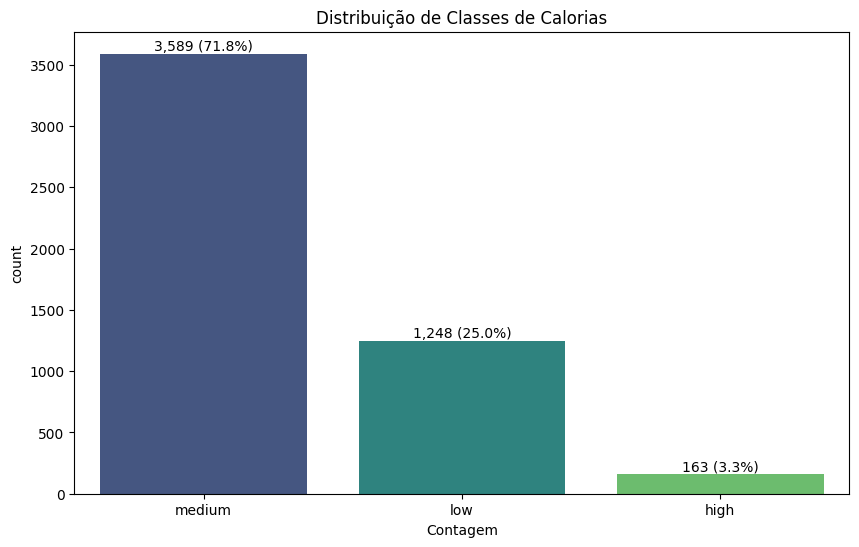

In [ ]:
plt.figure(figsize=(10, 6))
# gráfico de barras simples
ax = sns.countplot(x='Classe_de_Calorias', data=dafr_Calorias, hue='Classe_de_Calorias', palette='viridis', legend=False)
plt.title('Distribuição de Classes de Calorias')
plt.xlabel('Contagem')

# Calcular as contagens e porcentagens
total = len(dafr_Calorias)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(f'{int(p.get_height()):,.0f} ({percentage})', (x, y), ha='center', va='bottom', fontsize=10, color='black')

plt.show()

Observei que a contagem de refeições acima, classificadas como 'low' (baixa), 'medium' (média) ou 'high' (alta) em termos de calorias. foi identificado que as refeições classificadas como **'high' (alta)** é maior que as outras com *71%* de todas contagem, seguida pela **'medium' (média)** com *25%* a **low (baixa)** com a menor porcentagem *3,3%*. Evidenciando que é um datasets com uma distribuição não uniforme entre as classes, então dos dados estão desbalanceados.

**(Revisado)**

In [ ]:
# Seleciona as 5 primeiras colunas (macronutrientes)
macronutrientes = dafr_Calorias.iloc[:, :5]

# Define os coeficientes de caloria por grama para cada macronutriente
coeficientes_calorias = np.array([4, 4, 9, 2, 4])


# Multiplica os macronutrientes pelos seus respectivos coeficientes
calorias_por_macronutriente = macronutrientes.mul(coeficientes_calorias, axis=1);


# Exibe as 10 primeiras linhas dos valores das 5 primeiras colunas
print("Valores das 5 primeiras colunas em gramas (10 primeiras linhas):\n")
print(macronutrientes.head(10))
print("-----------------------------------------------------------------")


# Mostra o resultado das 10 primeiras linhas das 5 primeiras Colunas
print("Transformar em Kcal (10 primeiras linhas):")
print("Cálculos (Carboidrato/g x 4 - Proteina/g x 4 - Gordura/g x 9:")
print("Fibra/g x 2 - Acucar/g x 4):\n")
print(calorias_por_macronutriente.head(10))
print("-----------------------------------------------------------------")


Valores das 5 primeiras colunas em gramas (10 primeiras linhas):

   Carboidrato/g  Proteina/g  Gordura/g  Fibra/g  Acucar/g
0           22.5        65.2       13.7      9.9      26.7
1           15.9        20.7       16.8      7.6      15.0
2           28.3        62.4       14.5     10.8      15.3
3           23.3        18.6        7.9     17.0       0.2
4           30.8        55.1       31.9     12.5       7.2
5           35.5        72.8       19.6      6.7      11.9
6           16.1        45.1        9.8     12.5      21.0
7           38.1        23.1       17.1      0.0       5.6
8           31.6        43.3       17.4      5.3      17.4
9           21.4        76.1       18.1      2.0      23.0
-----------------------------------------------------------------
Transformar em Kcal (10 primeiras linhas):
Cálculos (Carboidrato/g x 4 - Proteina/g x 4 - Gordura/g x 9:
Fibra/g x 2 - Acucar/g x 4):

   Carboidrato/g  Proteina/g  Gordura/g  Fibra/g  Acucar/g
0           90.0       26

In [ ]:
# Soma os valores das colunas por linha
soma_primeiras_5 = calorias_por_macronutriente.sum(axis=1)

# Mostra o resultado das 10 primeiras linhas
print("Soma das calorias (Kcal), transformadas, com as 5 primeiras colunas (10 primeiras linhas):")
print(soma_primeiras_5.head(10))
print("-----------------------------------------------------------------")

# Exibe as 10 primeiras linhas do valor 'Calorias/Kcal'
print("\nValores do campo original da tabela 'Calorias/Kcal' - (10 primeiras linhas):")
print(dafr_Calorias['Calorias/Kcal'].head(10))

Soma das calorias (Kcal), transformadas, com as 5 primeiras colunas (10 primeiras linhas):
0    600.7
1    372.8
2    576.1
3    273.5
4    684.5
5    670.6
6    442.0
7    421.1
8    536.4
9    648.9
dtype: float64
-----------------------------------------------------------------

Valores do campo original da tabela 'Calorias/Kcal' - (10 primeiras linhas):
0    479.0
1    316.0
2    524.0
3    250.0
4    602.0
5    634.0
6    374.0
7    379.0
8    418.0
9    566.0
Name: Calorias/Kcal, dtype: float64


Gráfico de linhas com a comparação entre o campo original **'Calorias/Kcal'** com o valor da Variável **soma_primeiras_5**

**(Revisado)**

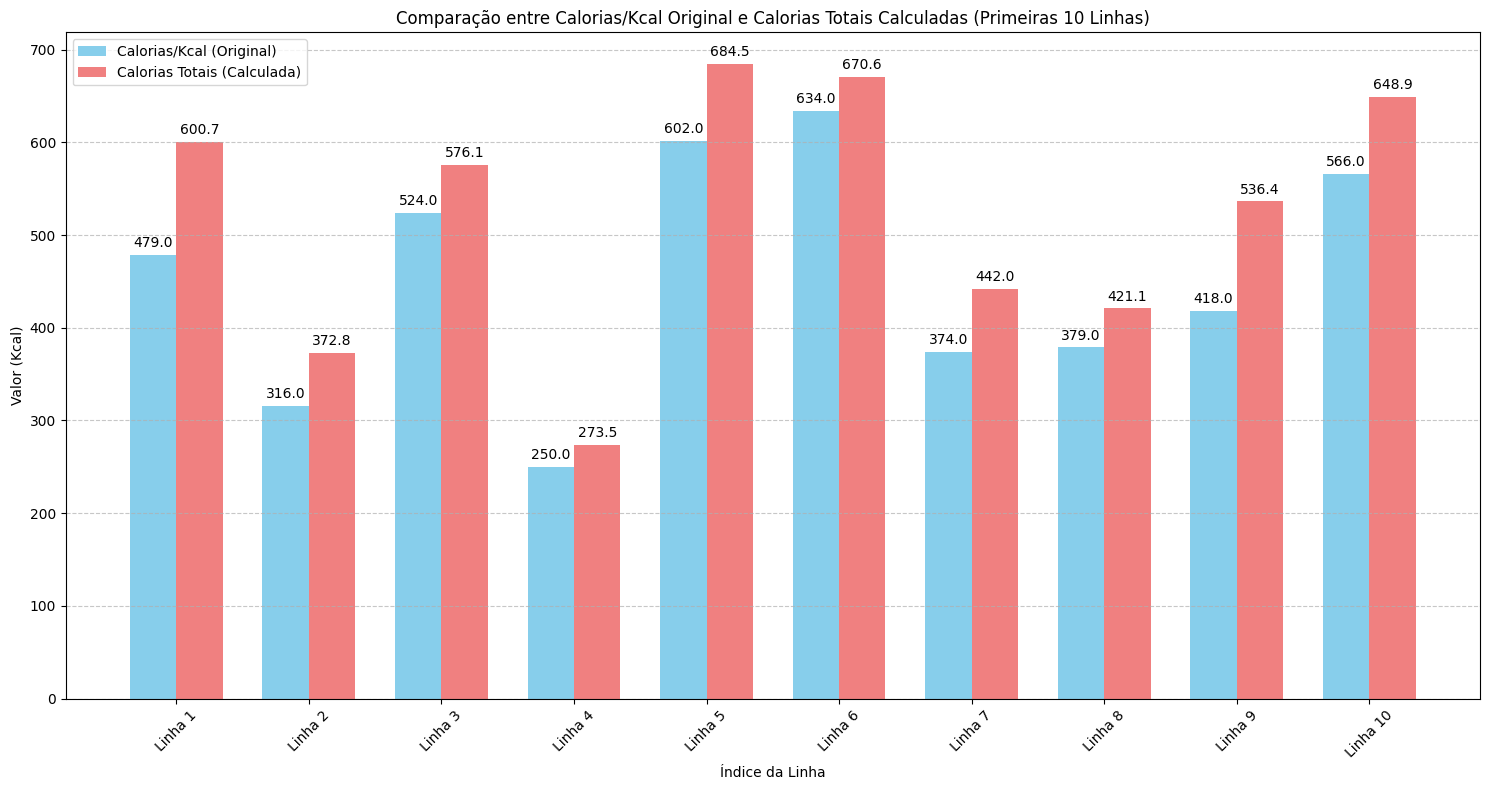

In [ ]:
# obtendo as 10 primeiras linhas e comparando
calorias_original_10 = dafr_Calorias['Calorias/Kcal'].head(10)
calorias_calculada_10 = soma_primeiras_5.head(10)

# criando um index para as barras
indices = np.arange(len(calorias_original_10))
bar_width = 0.35

plt.figure(figsize=(15, 8))

# Plot original 'Calorias/Kcal'
bars1 = plt.bar(indices - bar_width/2, calorias_original_10, bar_width, label='Calorias/Kcal (Original)', color='skyblue')

# Plot calculado 'soma_primeiras_5'
bars2 = plt.bar(indices + bar_width/2, calorias_calculada_10, bar_width, label='Calorias Totais (Calculada)', color='lightcoral')

# adicionando os valores no topo da barra
for bar in bars1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, round(yval, 1), ha='center', va='bottom')

for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, round(yval, 1), ha='center', va='bottom')

plt.xlabel('Índice da Linha')
plt.ylabel('Valor (Kcal)')
plt.title('Comparação entre Calorias/Kcal Original e Calorias Totais Calculadas (Primeiras 10 Linhas)')
plt.xticks(indices, [f'Linha {i}' for i in range(1, 11)], rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Fui me certificar se os cálculos do atributo **Calorias/Kcal** estavam corretos.

Apliquei o valor de Kcal por gramas ingeridas dos macronutrientes, conforme regras abaixo, e calculei as 5 primeiras atributos (**Carboidrato/g; Proteina/g; Gordura/g; Fibra/g e Acucar/g**) e depois somei todos os resultados na variável **soma_primeiras_5**.


*Regras para formar o valor dos dados do atributo* ***Calorias:***

  Carboidrato → 4 kcal por grama ingerido.

  Proteína → 4 kcal por grama ingerido.

  Gordura → 9 kcal por grama ingerido.

  Fibra → 2 kcal por grama ingerido.

  Açúcar → 4 kcal por grama ingerido.

  Multiplica-se as Kcal por gramas de macronutrientes ingeridos e depois somas esses valores de todos macronutrientes:

  EX:
  
  20g de Carboidrato - 20x4 = 80Kcal

  10g de Proteína - 10x4 = 40Kcal

  20g de Gordura - 20x9 = 180Kcal

  20g de Fibra - 20x2 = 40Kcal

  20g de Açúcar - 15x4 = 60Kcal

   Total de Calorias: 80Kcal+40Kcal+180Kcal+40Kcal+40Kcal = 400Kcal


Na análise, percebi que no resultado da variável **soma_primeiras_5** que é a soma de todos macronutrientes, em Kcal, está diferente do cálculo do atributo - ***Calorias/Kcal***

**(Revisado)**




## Conclusão (Revisado)

A conclusão foi que o cálculo original do atributo **Calorias/Kcal** do Dataset ***Calorias***, não está com o cálculo correto.

Isso influência na determinação do atributo categórico **Classe_de_Calorias**, que informa se consumos de todos os Macronutriente em Kcal foi ***Baixo***, ***Médio*** ou ***Alto***.

Além dos dados de **Classe_de_Calorias** estarem desbalanceado.

##Solução para resolver o problema de Cálculo errado: (Revisado)
Criar um novo atributo e recalcular os valores de acordo com a regra de **Calorias (Kcal)** de recalcular os valores.

Além de criar e popular novos atributos para realizar a análise.


Incluí os seguintes campos, com dados sintéticos, no dataset original (Calorie Dataset) para poder testar minhas Hipótestes:
- ***UF:*** Em siglas
- ***Idade:*** Idade de 18 a 81 anos
- ***Sexo:*** ***F*** - Feminio, ***M*** - Masculino, ***O*** - Outros
- ***Refeição:*** Café da manhã, Almoço, Jantar, Lanche
- ***Calorias Totais:*** É o resultado do seguinte cálculo:

  Carboidrato → 4 kcal por grama ingerido.

  Proteína → 4 kcal por grama ingerido.

  Gordura → 9 kcal por grama ingerido.

  Fibra → 2 kcal por grama ingerido.

  Açúcar → 4 kcal por grama ingerido.

  Multiplica-se as Kcal por gramas de macronutrientes ingeridos e depois somas esses valores de todos macronutrientes:

  EX:
  
  20g de Carboidrato - 20x4 = 80Kcal

  10g de Proteína - 10x4 = 40Kcal

  20g de Gordura - 20x9 = 180Kcal

  20g de Fibra - 20x2 = 40Kcal

  20g de Açúcar - 15x4 = 60Kcal

   Total de Calorias: 80Kcal+40Kcal+180Kcal+40Kcal+40Kcal = 400Kcal
- ***Nível de Calorias:*** (**Baixa** - Menor que 400 calorias, **Média** - Entre 400 e 699 calorias, **Alta** - Maior que 700 calorias)


# **Criando a Solução.  (Revisado)**

Criando os atributos e populando com dados aleatórios no início do DataSet:


*   **UF:** Em siglas
*   **Idade:** Idade de 18 a 81 anos
*   **Sexo:**  ***F*** - Feminino, ***M*** - Masculino, ***O*** - Outros
*   **Refeição:** Café da manhã, Almoço, Lanche, Jantar,

**OBS:** *Os atributos e dados originais serão mantidos.*




In [ ]:
# Importa as bibliotecas necessárias
import numpy as np
import pandas as pd

# Listas de valores para as novas colunas
uflist = ['AC', 'AL', 'AP', 'AM', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MT', 'MS', 'MG', 'PA', 'PB', 'PR', 'PE', 'PI', 'RJ', 'RN', 'RS', 'RO', 'RR', 'SC', 'SP', 'SE', 'TO']
sexo_list = ['F', 'M', 'O']
refeicao_list = ['CAFE DA MANHA', 'ALMOCO', 'JANTAR', 'LANCHE']

# Garante que dafr_Calorias_Nova é um DataFrame independente e não uma view
dafr_Calorias_Nova = dafr_Calorias.copy()

# Gera dados aleatórios para as novas colunas
new_uf = np.random.choice(uflist, size=len(dafr_Calorias_Nova))
new_idade = np.random.randint(18, 81, size=len(dafr_Calorias_Nova)) # Idade entre 18 e 80
new_sexo = np.random.choice(sexo_list, size=len(dafr_Calorias_Nova))
new_refeicao = np.random.choice(refeicao_list, size=len(dafr_Calorias_Nova))

# Cria um DataFrame temporário com as novas colunas
new_cols_df = pd.DataFrame({
    'UF': new_uf,
    'Idade': new_idade,
    'Sexo': new_sexo,
    'Refeição': new_refeicao
})

# Concatena as novas colunas no início do DataFrame existente
dafr_Calorias_Nova = pd.concat([new_cols_df, dafr_Calorias_Nova], axis=1)

print("DataFrame 'dafr_Calorias_Nova' atualizado com as novas colunas no início:")
display(dafr_Calorias_Nova.head())

DataFrame 'dafr_Calorias_Nova' atualizado com as novas colunas no início:


,UF,Idade,Sexo,Refeição,Carboidrato/g,Proteina/g,Gordura/g,Fibra/g,Acucar/g,Calorias/Kcal,Classe_de_Calorias
0,PE,58,M,CAFE DA MANHA,22.5,65.2,13.7,9.9,26.7,479.0,medium
1,ES,42,M,LANCHE,15.9,20.7,16.8,7.6,15.0,316.0,low
2,MS,18,M,ALMOCO,28.3,62.4,14.5,10.8,15.3,524.0,medium
3,PB,30,F,CAFE DA MANHA,23.3,18.6,7.9,17.0,0.2,250.0,low
4,SC,70,F,ALMOCO,30.8,55.1,31.9,12.5,7.2,602.0,medium


*Total de Instância após a inclusão dos novos campos:* **(Revisado)**

In [ ]:
print(f"Total de instâncias: {len(dafr_Calorias_Nova)}")
print("\nTipos de dados por coluna:")
print(dafr_Calorias_Nova.info())

Total de instâncias: 5000

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   UF                  5000 non-null   object 
 1   Idade               5000 non-null   int64  
 2   Sexo                5000 non-null   object 
 3   Refeição            5000 non-null   object 
 4   Carboidrato/g       5000 non-null   float64
 5   Proteina/g          5000 non-null   float64
 6   Gordura/g           5000 non-null   float64
 7   Fibra/g             5000 non-null   float64
 8   Acucar/g            5000 non-null   float64
 9   Calorias/Kcal       5000 non-null   float64
 10  Classe_de_Calorias  5000 non-null   object 
dtypes: float64(6), int64(1), object(4)
memory usage: 429.8+ KB
None


Criando os atributos e populando com dados aleatórios no fim do DataSet:


- ***Calorias Totais:*** com os seguintes cálculos:

  Carboidrato → 4 kcal por grama ingerido.

  Proteína → 4 kcal por grama ingerido.

  Gordura → 9 kcal por grama ingerido.

  Fibra → 2 kcal por grama ingerido.

  Açúcar → 4 kcal por grama ingerido.

  Multiplica-se as Kcal por gramas de macronutrientes ingeridos e depois somas esses valores de todos macronutrientes:

  EX:
  
  20g de Carboidrato - 20x4 = 80Kcal

  10g de Proteína - 10x4 = 40Kcal

  20g de Gordura - 20x9 = 180Kcal

  20g de Fibra - 20x2 = 40Kcal

  20g de Açúcar - 15x4 = 60Kcal

   Total de Calorias: 80Kcal+40Kcal+180Kcal+40Kcal+40Kcal = 400Kcal
- ***Nível de Calorias:*** com as seguintes regras: (**Baixa** - Menor que 400 calorias, **Média** - Entre 400 e 699 calorias, **Alta** - Maior que 700 calorias)


**OBS:** *Os atributos e dados originais serão mantidos.*

**(Revisado)**

In [ ]:
# Calcular 'Calorias_Totais'
dafr_Calorias_Nova['Calorias_Totais/Kcal'] = (
    dafr_Calorias_Nova['Carboidrato/g'] * 4 +
    dafr_Calorias_Nova['Proteina/g'] * 4 +
    dafr_Calorias_Nova['Gordura/g'] * 9 +
    dafr_Calorias_Nova['Fibra/g'] * 2 +
    dafr_Calorias_Nova['Acucar/g'] * 4
)

# Função para categorizar o nível de calorias
def categorizar_nivel_calorias(calorias):
    if calorias < 400:
        return 'BAIXA'
    elif 400 <= calorias <= 699:
        return 'MEDIA'
    else:
        return 'ALTA'

# Aplicar a função para criar a coluna 'Nível_Calorias'
dafr_Calorias_Nova['Nível_Calorias'] = dafr_Calorias_Nova['Calorias_Totais/Kcal'].apply(categorizar_nivel_calorias)

print("DataFrame 'dafr_Calorias_Nova' atualizado com 'Calorias_Totais' e 'Nível_Calorias':")
display(dafr_Calorias_Nova.head(15))

DataFrame 'dafr_Calorias_Nova' atualizado com 'Calorias_Totais' e 'Nível_Calorias':


,UF,Idade,Sexo,Refeição,Carboidrato/g,Proteina/g,Gordura/g,Fibra/g,Acucar/g,Calorias/Kcal,Classe_de_Calorias,Calorias_Totais/Kcal,Nível_Calorias
0,PE,58,M,CAFE DA MANHA,22.5,65.2,13.7,9.9,26.7,479.0,medium,600.7,MEDIA
1,ES,42,M,LANCHE,15.9,20.7,16.8,7.6,15.0,316.0,low,372.8,BAIXA
2,MS,18,M,ALMOCO,28.3,62.4,14.5,10.8,15.3,524.0,medium,576.1,MEDIA
3,PB,30,F,CAFE DA MANHA,23.3,18.6,7.9,17.0,0.2,250.0,low,273.5,BAIXA
4,SC,70,F,ALMOCO,30.8,55.1,31.9,12.5,7.2,602.0,medium,684.5,MEDIA
5,MG,43,F,CAFE DA MANHA,35.5,72.8,19.6,6.7,11.9,634.0,medium,670.6,MEDIA
6,MG,54,M,JANTAR,16.1,45.1,9.8,12.5,21.0,374.0,low,442.0,MEDIA
7,PE,44,M,ALMOCO,38.1,23.1,17.1,0.0,5.6,379.0,low,421.1,MEDIA
8,MA,19,M,LANCHE,31.6,43.3,17.4,5.3,17.4,418.0,medium,536.4,MEDIA
9,RR,52,F,JANTAR,21.4,76.1,18.1,2.0,23.0,566.0,medium,648.9,MEDIA


In [ ]:
# Mostra o resultado das 10 primeiras linhas
print("Soma das calorias (Kcal), transformadas, com as 5 primeiras colunas (10 primeiras linhas):")
print(soma_primeiras_5.head(10))
print("-----------------------------------------------------------------")

# Exibe as 10 primeiras linhas do valor 'Calorias/Kcal'
print("\nValores do campo original da tabela 'Calorias/Kcal' - (10 primeiras linhas):")
print(dafr_Calorias_Nova['Calorias_Totais/Kcal'].head(10))

Soma das calorias (Kcal), transformadas, com as 5 primeiras colunas (10 primeiras linhas):
0    600.7
1    372.8
2    576.1
3    273.5
4    684.5
5    670.6
6    442.0
7    421.1
8    536.4
9    648.9
dtype: float64
-----------------------------------------------------------------

Valores do campo original da tabela 'Calorias/Kcal' - (10 primeiras linhas):
0    600.7
1    372.8
2    576.1
3    273.5
4    684.5
5    670.6
6    442.0
7    421.1
8    536.4
9    648.9
Name: Calorias_Totais/Kcal, dtype: float64


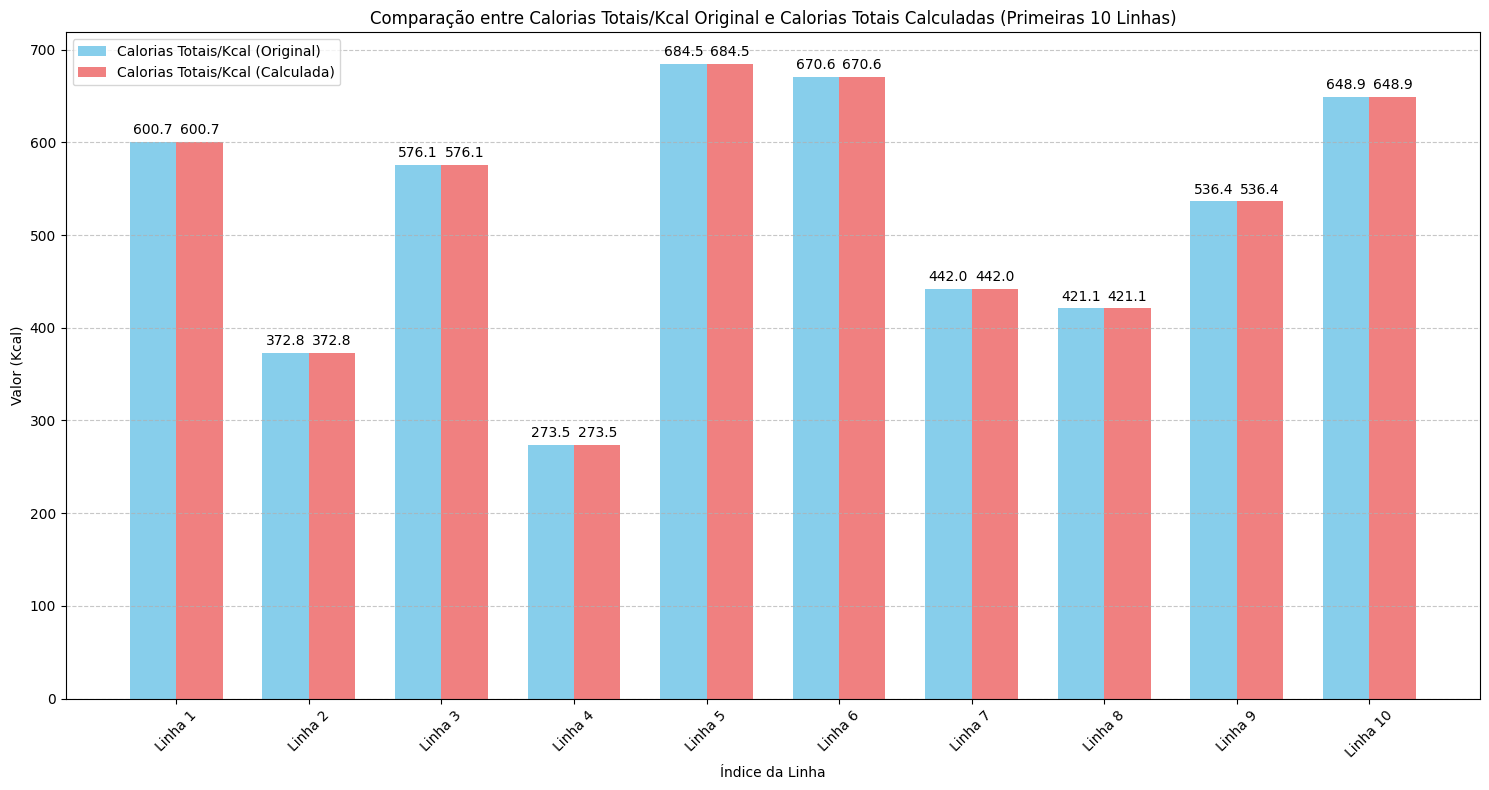

In [ ]:
# obtendo as 10 primeiras linhas e comparando
calorias_original_10 = dafr_Calorias_Nova['Calorias_Totais/Kcal'].head(10)
calorias_calculada_10 = soma_primeiras_5.head(10)

# criando um index para as barras
indices = np.arange(len(calorias_original_10))
bar_width = 0.35

plt.figure(figsize=(15, 8))

# Plot original 'Calorias/Kcal'
bars1 = plt.bar(indices - bar_width/2, calorias_original_10, bar_width, label='Calorias Totais/Kcal (Original)', color='skyblue')

# Plot calculado 'soma_primeiras_5'
bars2 = plt.bar(indices + bar_width/2, calorias_calculada_10, bar_width, label='Calorias Totais/Kcal (Calculada)', color='lightcoral')

# adicionando os valores no topo da barra
for bar in bars1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, round(yval, 1), ha='center', va='bottom')

for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, round(yval, 1), ha='center', va='bottom')

plt.xlabel('Índice da Linha')
plt.ylabel('Valor (Kcal)')
plt.title('Comparação entre Calorias Totais/Kcal Original e Calorias Totais Calculadas (Primeiras 10 Linhas)')
plt.xticks(indices, [f'Linha {i}' for i in range(1, 11)], rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

*Total de Instância após a inclusão dos novos campos:*

**(Revisado)**


In [ ]:
print(f"Total de instâncias: {len(dafr_Calorias_Nova)}")
print("\nTipos de dados por coluna:")
print(dafr_Calorias_Nova.info())

Total de instâncias: 5000

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   UF                    5000 non-null   object 
 1   Idade                 5000 non-null   int64  
 2   Sexo                  5000 non-null   object 
 3   Refeição              5000 non-null   object 
 4   Carboidrato/g         5000 non-null   float64
 5   Proteina/g            5000 non-null   float64
 6   Gordura/g             5000 non-null   float64
 7   Fibra/g               5000 non-null   float64
 8   Acucar/g              5000 non-null   float64
 9   Calorias/Kcal         5000 non-null   float64
 10  Classe_de_Calorias    5000 non-null   object 
 11  Calorias_Totais/Kcal  5000 non-null   float64
 12  Nível_Calorias        5000 non-null   object 
dtypes: float64(7), int64(1), object(5)
memory usage: 507.9+ KB
None


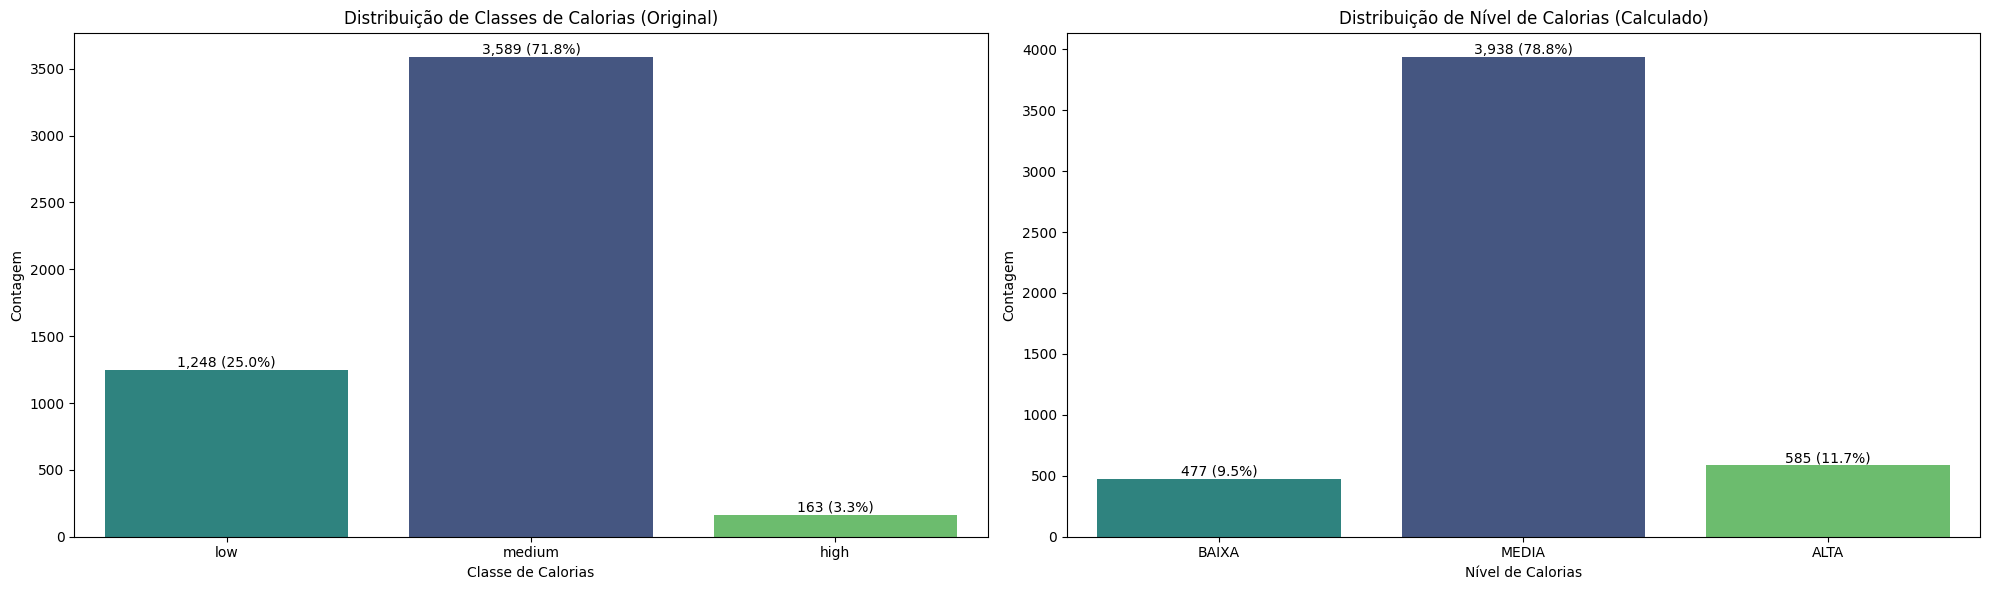

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Gráfico 1: Distribuição de Classes de Calorias (Original)
ax1 = sns.countplot(x='Classe_de_Calorias', data=dafr_Calorias, hue='Classe_de_Calorias', palette='viridis', legend=False, order=['low', 'medium', 'high'], ax=axes[0])
ax1.set_title('Distribuição de Classes de Calorias (Original)')
ax1.set_xlabel('Classe de Calorias')
ax1.set_ylabel('Contagem')

total_original = len(dafr_Calorias)
for p in ax1.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total_original)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax1.annotate(f'{int(p.get_height()):,.0f} ({percentage})', (x, y), ha='center', va='bottom', fontsize=10, color='black')

# Gráfico 2: Distribuição de Nível de Calorias (Calculado)
ax2 = sns.countplot(x='Nível_Calorias', data=dafr_Calorias_Nova, hue='Nível_Calorias', palette='viridis', legend=False, order=['BAIXA', 'MEDIA', 'ALTA'], ax=axes[1])
ax2.set_title('Distribuição de Nível de Calorias (Calculado)')
ax2.set_xlabel('Nível de Calorias')
ax2.set_ylabel('Contagem')

total_nova = len(dafr_Calorias_Nova)
for p in ax2.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total_nova)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax2.annotate(f'{int(p.get_height()):,.0f} ({percentage})', (x, y), ha='center', va='bottom', fontsize=10, color='black')

plt.tight_layout()
plt.show()

In [66]:
# Codigo que mostre 10 linhas que informa que no atributo Classe_de_Calorias igual a low
#e o atributo Nível_Calorias seja diferente de 'BAIXO'
linhas_filtradas_low = dafr_Calorias_Nova[
    (dafr_Calorias_Nova['Classe_de_Calorias'] == 'low') &
    (dafr_Calorias_Nova['Nível_Calorias'] != 'BAIXA')
]

# Exibir as primeiras 10 linhas do resultado com as colunas solicitadas
print("10 linhas onde 'Classe_de_Calorias' é 'low' e 'Nível_Calorias' é diferente de 'BAIXA':\n")
display(linhas_filtradas_low[['Calorias/Kcal', 'Classe_de_Calorias', 'Calorias_Totais/Kcal', 'Nível_Calorias']].head(10))

10 linhas onde 'Classe_de_Calorias' é 'low' e 'Nível_Calorias' é diferente de 'BAIXA':



,Calorias/Kcal,Classe_de_Calorias,Calorias_Totais/Kcal,Nível_Calorias
6,374.0,low,442.0,MEDIA
7,379.0,low,421.1,MEDIA
18,355.0,low,513.5,MEDIA
22,341.0,low,503.2,MEDIA
25,352.0,low,441.8,MEDIA
29,367.0,low,458.4,MEDIA
33,378.0,low,464.8,MEDIA
37,395.0,low,532.7,MEDIA
43,345.0,low,484.6,MEDIA
52,355.0,low,458.7,MEDIA


In [61]:
# Codigo que mostre 10 linhas que informa que no atributo Classe_de_Calorias igual a medium
#e o atributo Nível_Calorias seja diferente de 'MEDIA'
linhas_filtradas_medium = dafr_Calorias_Nova[
    (dafr_Calorias_Nova['Classe_de_Calorias'] == 'medium') &
    (dafr_Calorias_Nova['Nível_Calorias'] != 'MEDIA')
]

# Exibir as primeiras 10 linhas do resultado
print("Linhas onde 'Classe_de_Calorias' é 'medium' e 'Nível_Calorias' é diferente de 'MEDIA'\n:")
display(linhas_filtradas_medium[['Calorias/Kcal', 'Classe_de_Calorias', 'Calorias_Totais/Kcal', 'Nível_Calorias']].head(10))

Linhas onde 'Classe_de_Calorias' é 'medium' e 'Nível_Calorias' é diferente de 'MEDIA'
:


,Calorias/Kcal,Classe_de_Calorias,Calorias_Totais/Kcal,Nível_Calorias
50,565.0,medium,710.3,ALTA
51,643.0,medium,739.4,ALTA
56,689.0,medium,752.6,ALTA
58,654.0,medium,806.7,ALTA
70,658.0,medium,816.5,ALTA
76,643.0,medium,728.6,ALTA
78,668.0,medium,718.1,ALTA
88,630.0,medium,779.1,ALTA
90,650.0,medium,740.9,ALTA
94,666.0,medium,779.0,ALTA


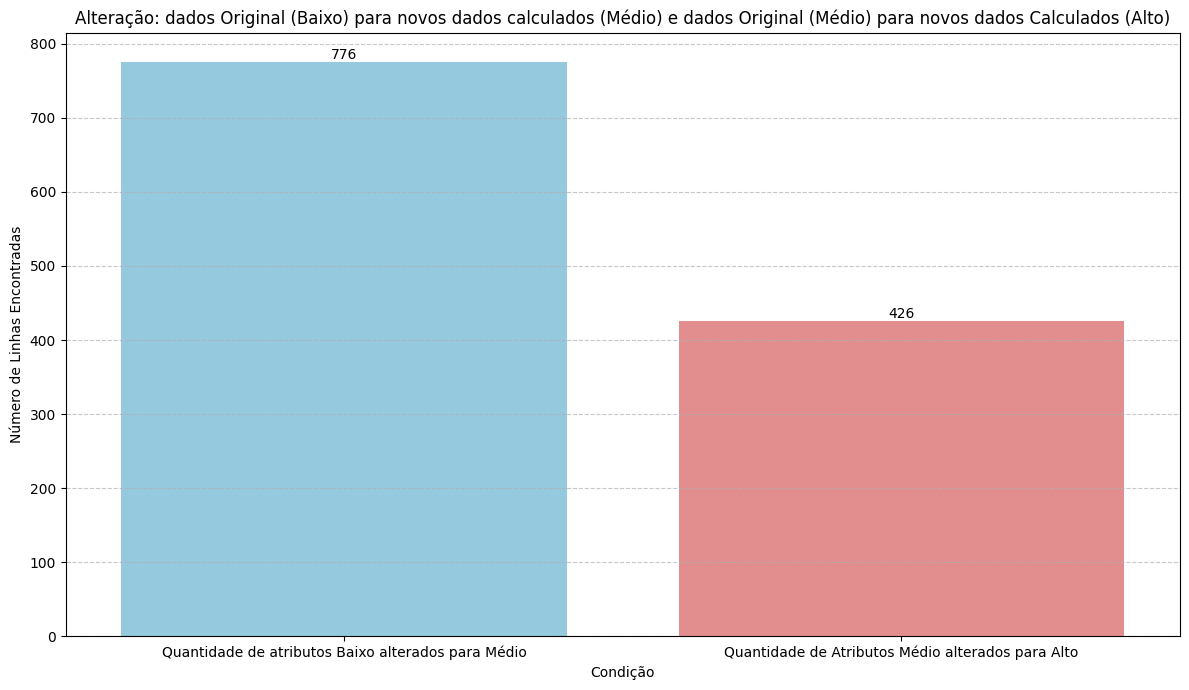

In [67]:
# Contar linhas onde Classe_de_Calorias é 'low' e Nível_Calorias é 'MEDIA'
count_low_media = dafr_Calorias_Nova[
    (dafr_Calorias_Nova['Classe_de_Calorias'] == 'low') &
    (dafr_Calorias_Nova['Nível_Calorias'] == 'MEDIA')
].shape[0]

# Contar linhas onde Classe_de_Calorias é 'low' e Nível_Calorias é 'ALTA'
count_low_alta = dafr_Calorias_Nova[
    (dafr_Calorias_Nova['Classe_de_Calorias'] == 'medium') &
    (dafr_Calorias_Nova['Nível_Calorias'] == 'ALTA')
].shape[0]

# Criar um DataFrame para o gráfico
df_plot = pd.DataFrame({
    'Condição': ['Quantidade de atributos Baixo alterados para Médio', 'Quantidade de Atributos Médio alterados para Alto'],
    'Contagem': [count_low_media, count_low_alta]
})

plt.figure(figsize=(12, 7))
ax = sns.barplot(x='Condição', y='Contagem', hue='Condição', data=df_plot, palette=['skyblue', 'lightcoral'])

plt.title('Alteração: dados Original (Baixo) para novos dados calculados (Médio) e dados Original (Médio) para novos dados Calculados (Alto)')
plt.xlabel('Condição')
plt.ylabel('Número de Linhas Encontradas')

# Adicionar os valores no topo das barras
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Com o novo campo **Calorias Totais**  inserido e calculado, o valor desse atibuto ficou diferente do atributo original **Calorias/Kcal**.

Isso fez com que o atributo de categorização **Nível_Calorias** também se alteraram com relação dos atributos de categorização inicial **Classe_de_Calorias**.

Percebam nos exemplos acima:

**(Revisado)**

Foi gerado um novo DataFreme: ***dafr_Refeicao*** para indicar que cada linha representa uma Refeição.

**(Revisado)**

In [ ]:
colunas_para_dafr_Refeicao = [
    'UF', 'Idade', 'Sexo', 'Refeição',
    'Carboidrato/g', 'Proteina/g', 'Gordura/g', 'Fibra/g', 'Acucar/g',
    'Calorias_Totais/Kcal', 'Nível_Calorias'
]

dafr_Refeicao = dafr_Calorias_Nova[colunas_para_dafr_Refeicao].copy()

print("Novo DataFrame 'dafr_Refeicao' criado com as colunas solicitadas:\n")
display(dafr_Refeicao.head())

Novo DataFrame 'dafr_Refeicao' criado com as colunas solicitadas:



,UF,Idade,Sexo,Refeição,Carboidrato/g,Proteina/g,Gordura/g,Fibra/g,Acucar/g,Calorias_Totais/Kcal,Nível_Calorias
0,SE,74,M,CAFE DA MANHA,22.5,65.2,13.7,9.9,26.7,600.7,MEDIA
1,PI,56,F,LANCHE,15.9,20.7,16.8,7.6,15.0,372.8,BAIXA
2,RN,40,M,LANCHE,28.3,62.4,14.5,10.8,15.3,576.1,MEDIA
3,SP,29,F,LANCHE,23.3,18.6,7.9,17.0,0.2,273.5,BAIXA
4,RN,37,O,JANTAR,30.8,55.1,31.9,12.5,7.2,684.5,MEDIA



# Total e Tipo das Instâncias depois da cinlusão de novos campos
Com a criação do Dataframe **dafr_Refeicao**, ele ficou com 5000 instâncias (observações), com 4 classes categóricas (*UF; Sexo; Refeição; Nível_Calorias*) do tipo (**object**), 1 características de medição (*Idade*) do tipo numérico (**int64**) e 6 características de medição (*Carboidrato/g;	Proteina/g;	Gordura/g;	Fibra/g;	Acucar/g;	Calorias_Totais/Kcal*) que são do tipo numérico(**float**).

In [ ]:
print(f"Total de instâncias: {len(dafr_Refeicao)}")
print("\nTipos de dados por coluna:")
print(dafr_Refeicao.info())

Total de instâncias: 5000

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   UF                    5000 non-null   object 
 1   Idade                 5000 non-null   int64  
 2   Sexo                  5000 non-null   object 
 3   Refeição              5000 non-null   object 
 4   Carboidrato/g         5000 non-null   float64
 5   Proteina/g            5000 non-null   float64
 6   Gordura/g             5000 non-null   float64
 7   Fibra/g               5000 non-null   float64
 8   Acucar/g              5000 non-null   float64
 9   Calorias_Totais/Kcal  5000 non-null   float64
 10  Nível_Calorias        5000 non-null   object 
dtypes: float64(6), int64(1), object(4)
memory usage: 429.8+ KB
None


# Análise de Dados

Nesta etapa de Análise de Dados Exploratória (EDA) sobre o dataset Calorias, visamos entender a distribuição, as relações e as características das variáveis, o que é crucial para as etapas subsequentes de pré-processamento e modelagem.

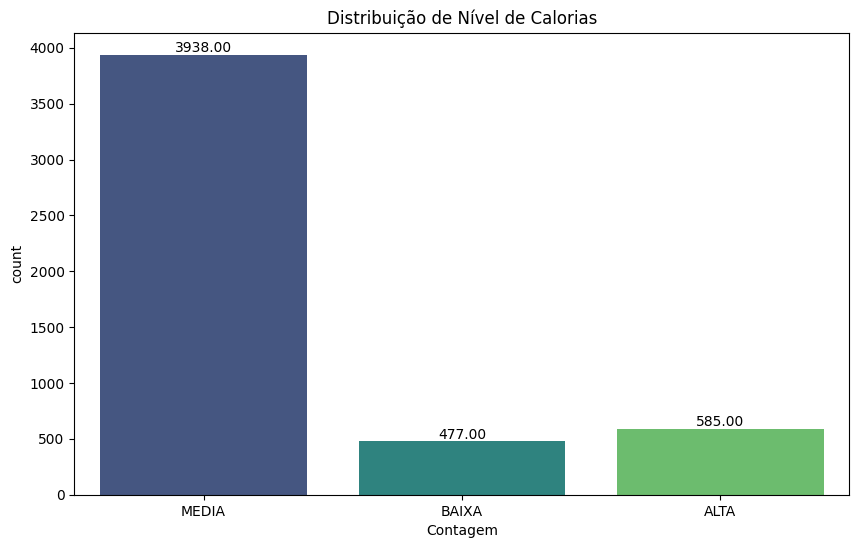

In [ ]:
plt.figure(figsize=(10, 6))
# gráfico de barras simples
ax = sns.countplot(x='Nível_Calorias', data=dafr_Refeicao, hue='Nível_Calorias', palette='viridis', legend=False)
plt.title('Distribuição de Nível de Calorias')
plt.xlabel('Contagem')
#plt.ylabel('Média de Calorias Totais (Kcal)')

# Adicionar os valores da média em cima das barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')


plt.show()

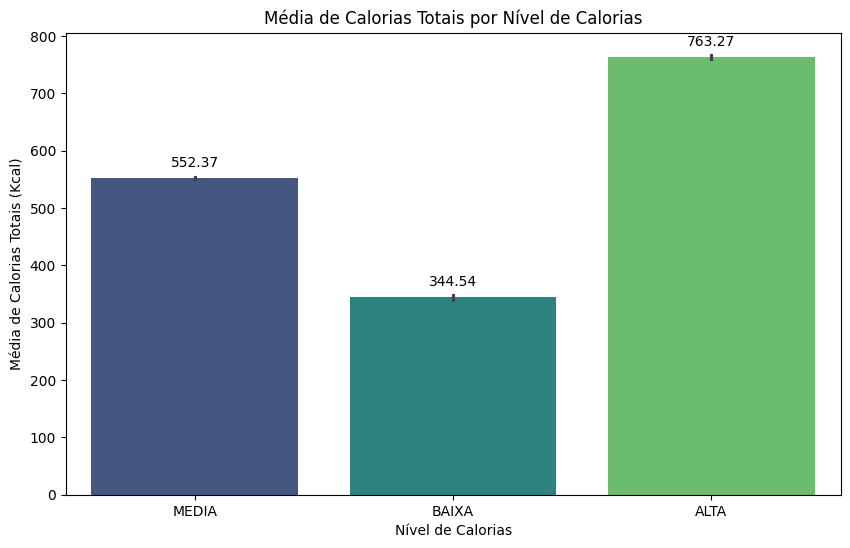

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Nível_Calorias', y='Calorias_Totais/Kcal', data=dafr_Refeicao, hue='Nível_Calorias', palette='viridis', legend=False)
plt.title('Média de Calorias Totais por Nível de Calorias')
plt.xlabel('Nível de Calorias')
plt.ylabel('Média de Calorias Totais (Kcal)')

# Adicionar os valores da média em cima das barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=6)


plt.show()

In [ ]:
# primeiras linhas
dafr_Refeicao.head()

,UF,Idade,Sexo,Refeição,Proteína/g,Carboidrato/g,Gordura/g,Fibra/g,Açucar/g,Calorias/Kcal,Classe de Calorias/Kcal,Calorias Totais/Kcal,Nível de Calorias
0,AP,30,M,LANCHE,22.5,65.2,13.7,9.9,26.7,479.0,medium,600.7,MEDIA
1,RS,20,F,LANCHE,15.9,20.7,16.8,7.6,15.0,316.0,low,372.8,BAIXA
2,PI,57,F,CAFE DA MANHA,28.3,62.4,14.5,10.8,15.3,524.0,medium,576.1,MEDIA
3,MS,61,M,CAFE DA MANHA,23.3,18.6,7.9,17.0,0.2,250.0,low,273.5,BAIXA
4,MS,66,M,ALMOCO,30.8,55.1,31.9,12.5,7.2,602.0,medium,684.5,MEDIA


## Total e Tipo das Instâncias

O dataset Iris possui 150 instâncias (observações), com 50 instâncias para cada uma das três espécies. As quatro características de medição são de tipo numérico (float), enquanto o atributo 'species' é categórico.

In [ ]:
print(f"Total de instâncias: {len(dafr_Refeicao)}")
print("\nTipos de dados por coluna:")
print(dafr_Refeicao.info())

Total de instâncias: 5000

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   UF                    5000 non-null   object 
 1   Idade                 5000 non-null   int64  
 2   Sexo                  5000 non-null   object 
 3   Refeição              5000 non-null   object 
 4   Carboidrato/g         5000 non-null   float64
 5   Proteina/g            5000 non-null   float64
 6   Gordura/g             5000 non-null   float64
 7   Fibra/g               5000 non-null   float64
 8   Acucar/g              5000 non-null   float64
 9   Calorias_Totais/Kcal  5000 non-null   float64
 10  Nível_Calorias        5000 non-null   object 
dtypes: float64(6), int64(1), object(4)
memory usage: 429.8+ KB
None


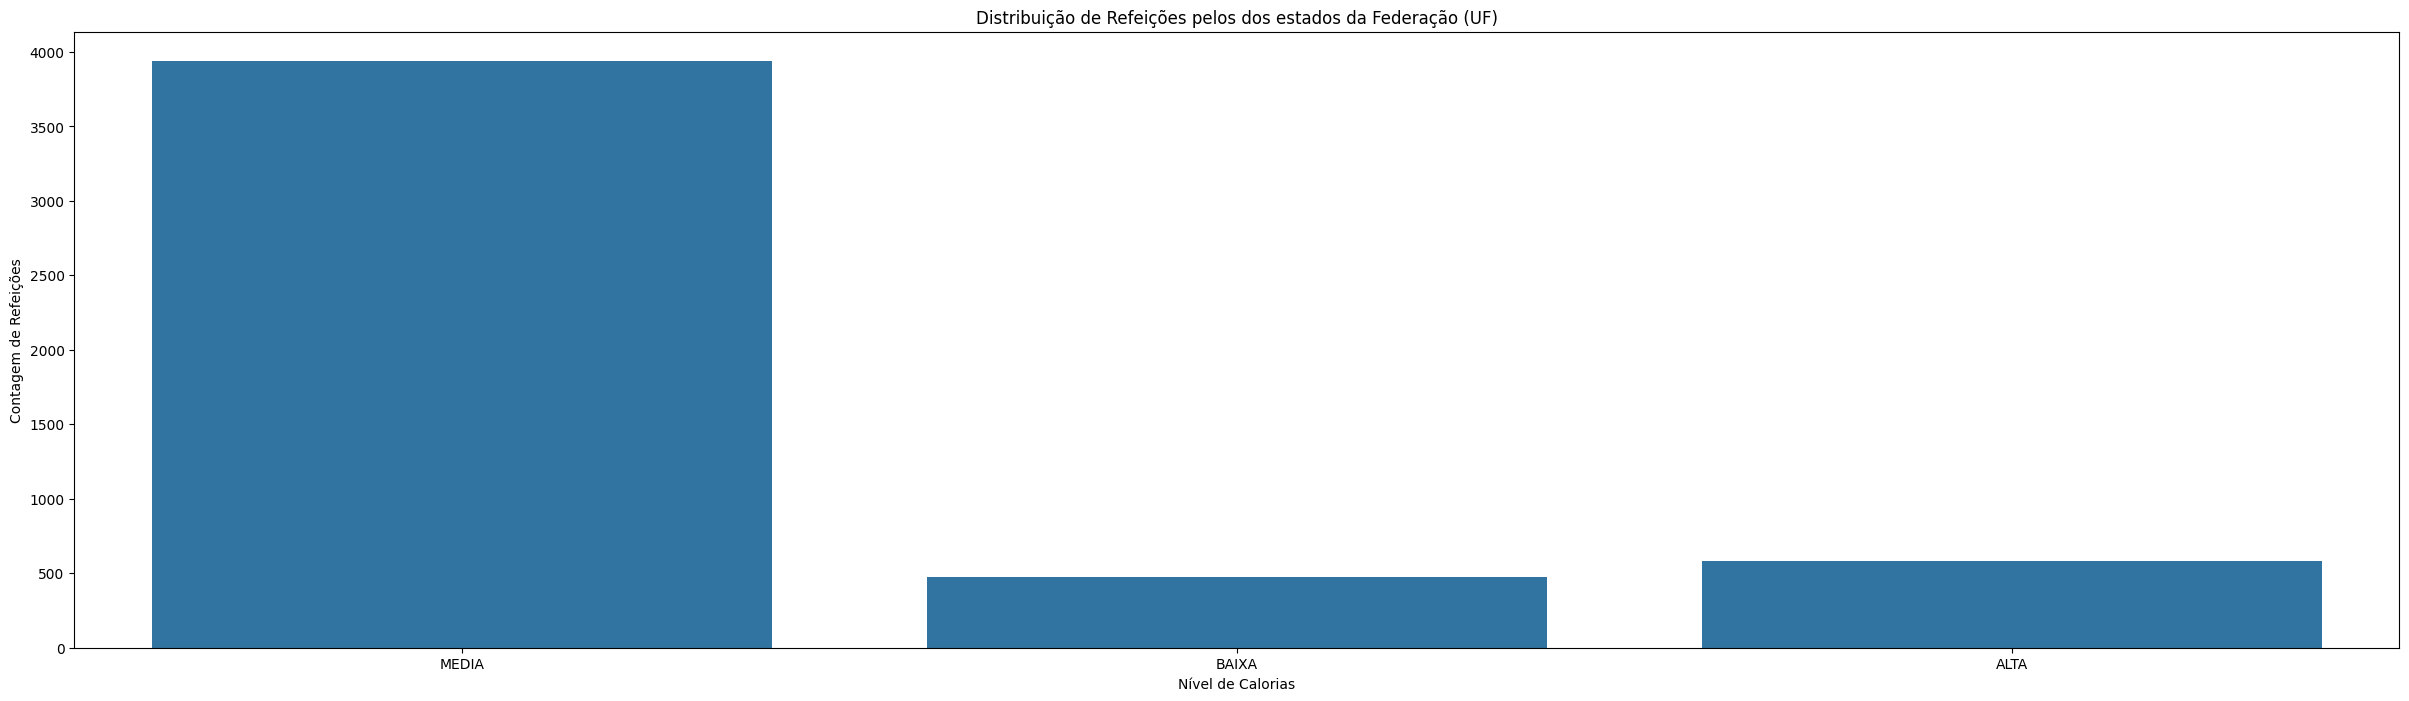

In [ ]:
plt.figure(figsize=(30, 8))
# gráfico de barras simples
sns.countplot(x='Nível de Calorias', data=dafr_Refeicao)
plt.title('Distribuição de Refeições pelos dos estados da Federação (UF)')
plt.xlabel('Nível de Calorias')
plt.ylabel('Contagem de Refeições')
plt.show()

In [ ]:
media_calorias_por_nivel = dafr_Refeicao.groupby('Nível de Calorias')['Calorias Totais/Kcal'].mean().reset_index()
display(media_calorias_por_nivel)

,Nível de Calorias,Calorias Totais/Kcal
0,ALTA,763.271966
1,BAIXA,344.426471
2,MEDIA,552.331835


A tabela acima mostra a média de calorias totais (`Calorias Totais/Kcal`) para cada `Nível de Calorias` presente no dataset `dafr_Refeicao`.

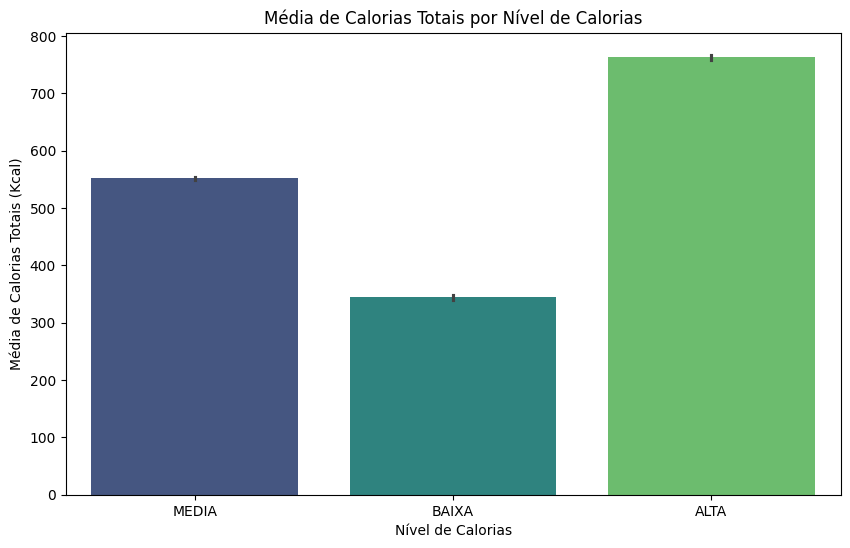

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Nível de Calorias', y='Calorias Totais/Kcal', data=dafr_Refeicao, palette='viridis', hue='Nível de Calorias', legend=False)
plt.title('Média de Calorias Totais por Nível de Calorias')
plt.xlabel('Nível de Calorias')
plt.ylabel('Média de Calorias Totais (Kcal)')
plt.show()

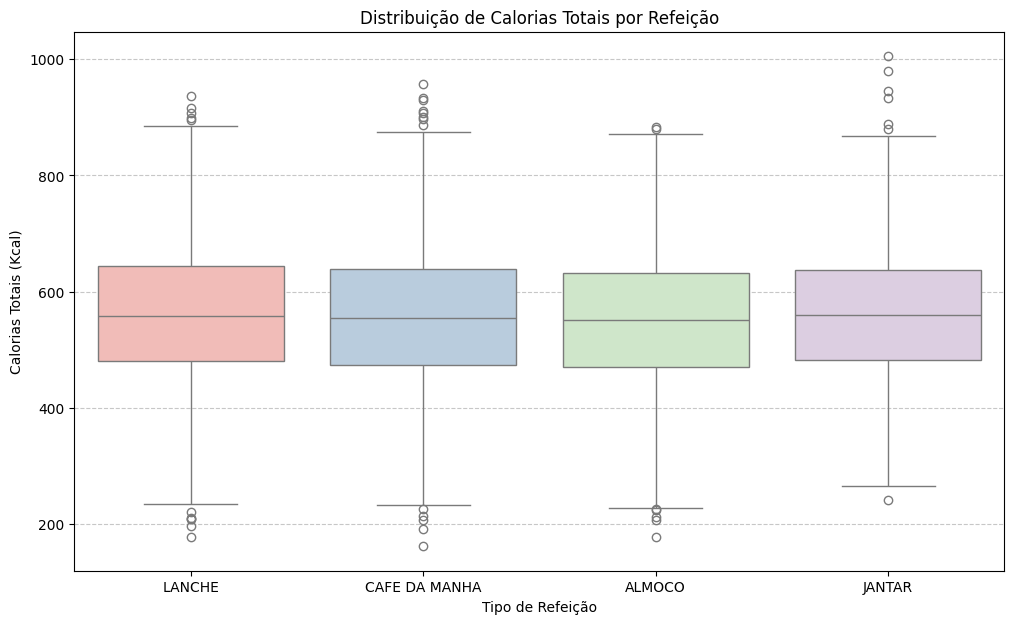

In [ ]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='Refeição', y='Calorias Totais/Kcal', data=dafr_Refeicao, palette='Pastel1', hue='Refeição', legend=False)
plt.title('Distribuição de Calorias Totais por Refeição')
plt.xlabel('Tipo de Refeição')
plt.ylabel('Calorias Totais (Kcal)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
correlation = dafr_Refeicao['Calorias Totais/Kcal'].corr(dafr_Refeicao['Idade'])
print(f"A correlação entre Calorias Totais e Idade é: {correlation:.2f}")

A correlação entre Calorias Totais e Idade é: 0.00


In [ ]:
display(dafr_Refeicao.describe())

,Idade,Proteína/g,Carboidrato/g,Gordura/g,Fibra/g,Açucar/g,Calorias/Kcal,Calorias Totais/Kcal
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,48.625000,25.076720,49.850420,20.105280,8.103620,15.088980,480.455800,557.219240
std,17.963566,9.907564,20.071407,7.933298,3.923217,9.298863,117.948845,120.666745
min,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,56.000000,162.300000
25%,33.000000,18.400000,36.300000,14.700000,5.300000,8.000000,400.000000,476.400000
50%,49.000000,25.100000,49.650000,20.100000,8.100000,14.900000,480.000000,556.300000
75%,64.000000,31.700000,63.525000,25.400000,10.800000,21.500000,561.250000,638.525000
max,80.000000,64.300000,120.600000,47.400000,25.900000,51.100000,975.000000,1005.100000


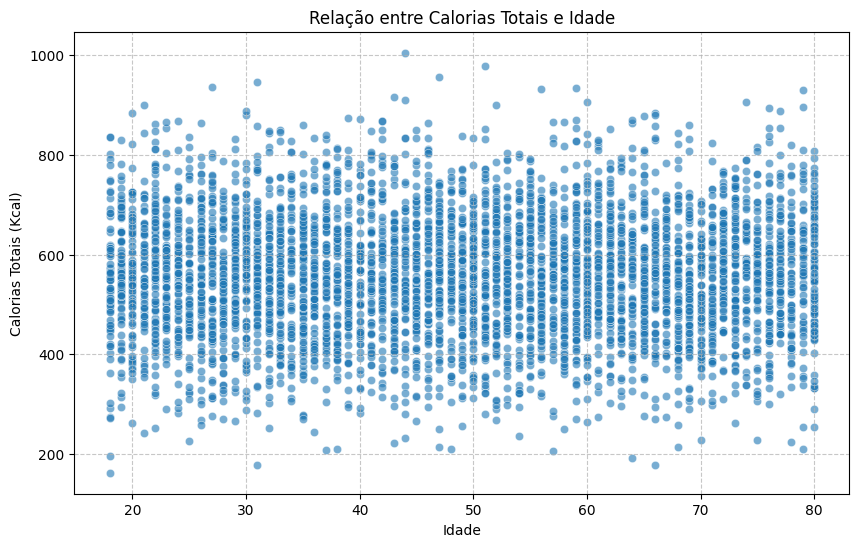

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Idade', y='Calorias Totais/Kcal', data=dafr_Refeicao, alpha=0.6)
plt.title('Relação entre Calorias Totais e Idade')
plt.xlabel('Idade')
plt.ylabel('Calorias Totais (Kcal)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

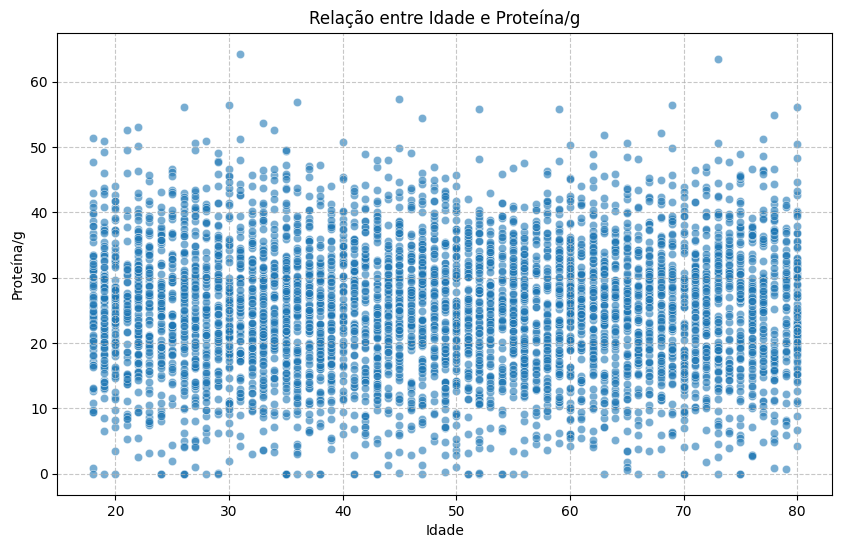

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Idade', y='Proteína/g', data=dafr_Refeicao, alpha=0.6)
plt.title('Relação entre Idade e Proteína/g')
plt.xlabel('Idade')
plt.ylabel('Proteína/g')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
numeric_cols = dafr_Refeicao.select_dtypes(include=np.number).columns
correlation_with_calories = dafr_Refeicao[numeric_cols].corr()['Calorias Totais/Kcal'].sort_values(ascending=False)
display(correlation_with_calories)

#Para identificar as variáveis com a correlação mais forte com 'Calorias Totais/Kcal',
#vou calcular a matriz de correlação para o DataFrame dafr_Refeicao e, em seguida,
#extrair e exibir as correlações com a variável 'Calorias Totais/Kcal'

,Calorias Totais/Kcal
Calorias Totais/Kcal,1.000000
Calorias/Kcal,0.918380
Carboidrato/g,0.658285
Gordura/g,0.593979
Proteína/g,0.330561
Açucar/g,0.319748
Fibra/g,0.052586
Idade,0.001330


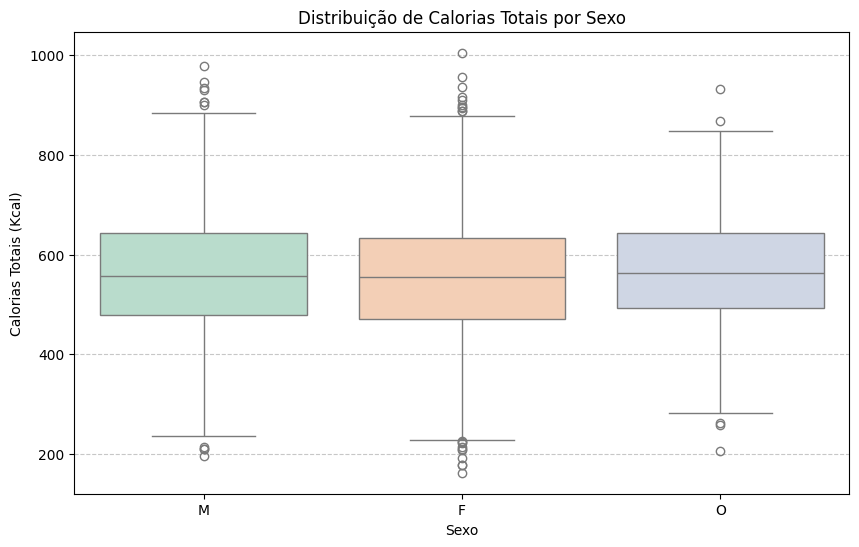

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Sexo', y='Calorias Totais/Kcal', data=dafr_Refeicao, palette='Pastel2', hue='Sexo', legend=False)
plt.title('Distribuição de Calorias Totais por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Calorias Totais (Kcal)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

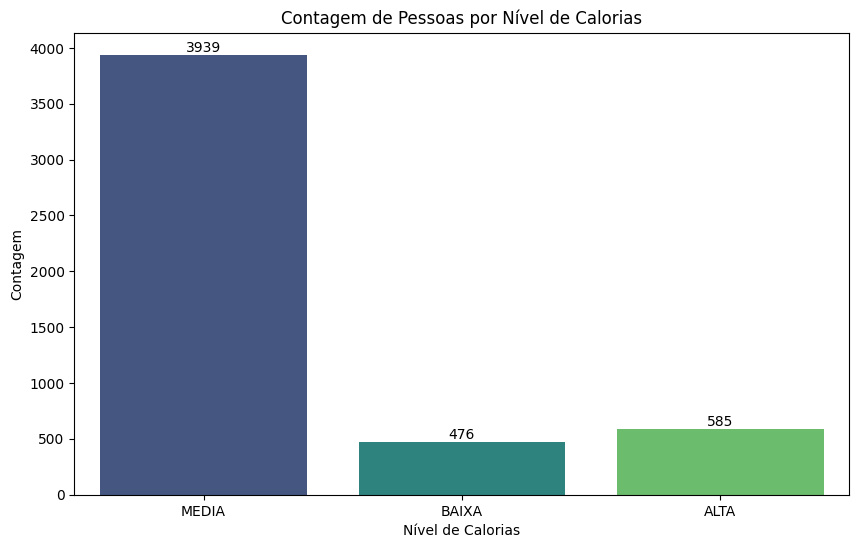

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Nível de Calorias', data=dafr_Refeicao, palette='viridis', hue='Nível de Calorias', legend=False)
plt.title('Contagem de Pessoas por Nível de Calorias')
plt.xlabel('Nível de Calorias')
plt.ylabel('Contagem')

# Adicionar contagem total em cima das barras
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container)

plt.show()

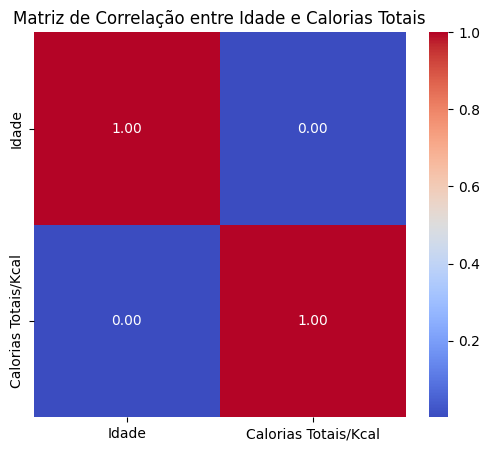

In [ ]:
correlation_matrix = dafr_Refeicao[['Idade', 'Calorias Totais/Kcal']].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação entre Idade e Calorias Totais')
plt.show()

In [ ]:
print(f"Total de instâncias: {len(dafr_Refeicao)}")
print("\nTipos de dados por coluna:")
print(dafr_Refeicao.info())

Total de instâncias: 5000

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UF                       5000 non-null   object 
 1   Idade                    5000 non-null   int64  
 2   Sexo                     5000 non-null   object 
 3   Refeição                 5000 non-null   object 
 4   Proteína/g               5000 non-null   float64
 5   Carboidrato/g            5000 non-null   float64
 6   Gordura/g                5000 non-null   float64
 7   Fibra/g                  5000 non-null   float64
 8   Açucar/g                 5000 non-null   float64
 9   Calorias/Kcal            5000 non-null   float64
 10  Classe de Calorias/Kcal  5000 non-null   object 
 11  Calorias Totais/Kcal     5000 non-null   float64
 12  Nível de Calorias        5000 non-null   object 
dtypes: float64(7), int64(1),

O gráfico de barras mostra que cada espécie de Íris (setosa, versicolor, virginica) possui 50 amostras, confirmando que o dataset é balanceado em termos de classes.

## Estatísticas Descritivas

Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis.

In [ ]:
# estatísticas descritivas básicas do dataset
dafr_Refeicao.describe()

,Idade,Proteína/g,Carboidrato/g,Gordura/g,Fibra/g,Açucar/g,Calorias/Kcal,Calorias Totais/Kcal
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,48.625000,25.076720,49.850420,20.105280,8.103620,15.088980,480.455800,557.219240
std,17.963566,9.907564,20.071407,7.933298,3.923217,9.298863,117.948845,120.666745
min,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,56.000000,162.300000
25%,33.000000,18.400000,36.300000,14.700000,5.300000,8.000000,400.000000,476.400000
50%,49.000000,25.100000,49.650000,20.100000,8.100000,14.900000,480.000000,556.300000
75%,64.000000,31.700000,63.525000,25.400000,10.800000,21.500000,561.250000,638.525000
max,80.000000,64.300000,120.600000,47.400000,25.900000,51.100000,975.000000,1005.100000


### Média

A média é uma medida de tendência central que representa o valor típico ou o ponto de equilíbrio de um conjunto de dados. É calculada somando-se todos os valores e dividindo-se pelo número total de observações. É sensível a valores extremos (outliers).

In [ ]:
# média dos atributos numéricos do dataset
dafr_Refeicao.describe().loc['mean']

,mean
Idade,48.62500
Proteína/g,25.07672
Carboidrato/g,49.85042
Gordura/g,20.10528
Fibra/g,8.10362
Açucar/g,15.08898
Calorias/Kcal,480.45580
Calorias Totais/Kcal,557.21924


Para mostrar a média, o gráfico de barras é geralmente a melhor opção. Ele permite comparar facilmente os valores médios entre diferentes categorias, tornando a visualização intuitiva e direta.


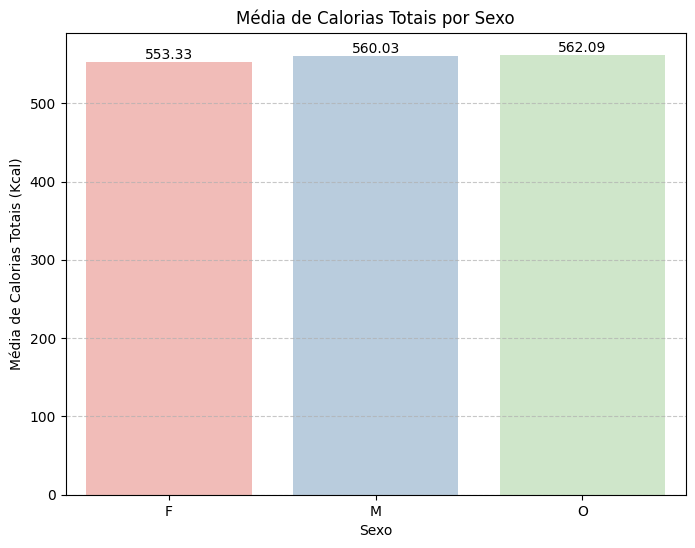

In [ ]:
media_calorias_por_sexo = dafr_Refeicao.groupby('Sexo')['Calorias Totais/Kcal'].mean().reset_index()

plt.figure(figsize=(8, 6))
ax = sns.barplot(x='Sexo', y='Calorias Totais/Kcal', data=media_calorias_por_sexo, palette='Pastel1', hue='Sexo', legend=False)
plt.title('Média de Calorias Totais por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Média de Calorias Totais (Kcal)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar os valores da média em cima das barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.show()

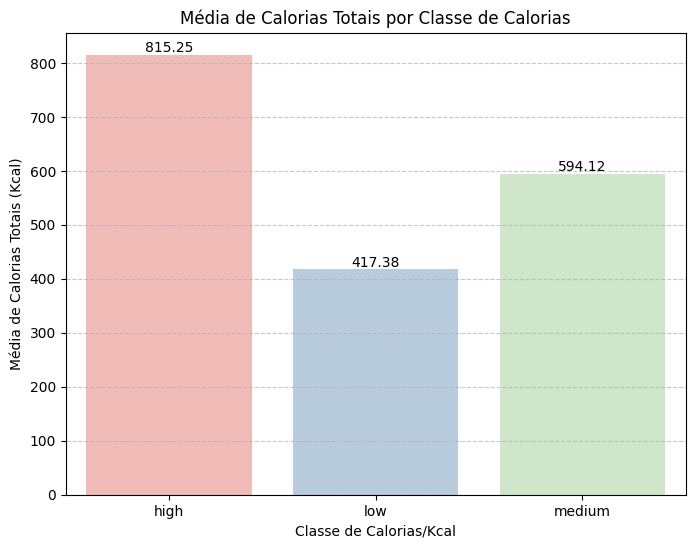

In [ ]:
media_calorias_por_nivelCaloria = dafr_Refeicao.groupby('Classe de Calorias/Kcal')['Calorias Totais/Kcal'].mean().reset_index()

plt.figure(figsize=(8, 6))
# Removido o parâmetro 'hue' pois a coluna 'Sexo' não está presente em 'media_calorias_por_idade'
ax = sns.barplot(x='Classe de Calorias/Kcal', y='Calorias Totais/Kcal', data=media_calorias_por_nivelCaloria, palette='Pastel1',hue='Classe de Calorias/Kcal', legend=False)
plt.title('Média de Calorias Totais por Classe de Calorias')
plt.xlabel('Classe de Calorias/Kcal')
plt.ylabel('Média de Calorias Totais (Kcal)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar os valores da média em cima das barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.show()

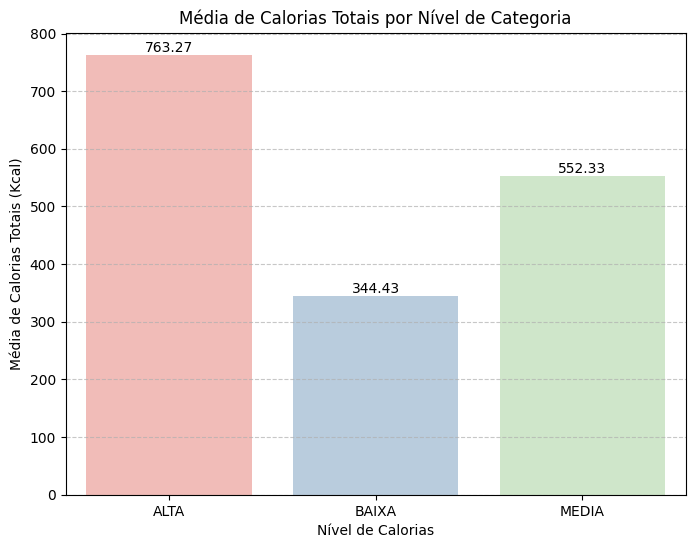

In [ ]:
media_calorias_por_nivelCaloria = dafr_Refeicao.groupby('Nível de Calorias')['Calorias Totais/Kcal'].mean().reset_index()

plt.figure(figsize=(8, 6))
ax = sns.barplot(x='Nível de Calorias', y='Calorias Totais/Kcal', data=media_calorias_por_nivelCaloria, palette='Pastel1',hue='Nível de Calorias', legend=False)
plt.title('Média de Calorias Totais por Nível de Calorias')
plt.xlabel('Nível de Calorias')
plt.ylabel('Média de Calorias Totais (Kcal)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar os valores da média em cima das barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.show()

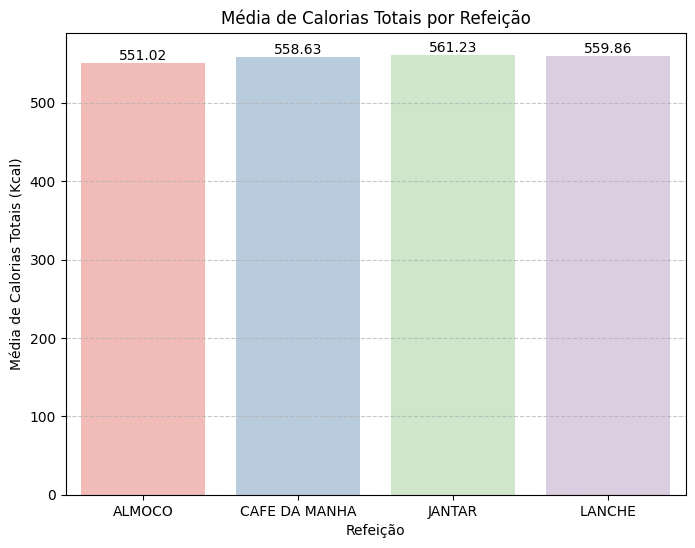

In [ ]:
media_calorias_por_nivelCaloria = dafr_Refeicao.groupby('Refeição')['Calorias Totais/Kcal'].mean().reset_index()

plt.figure(figsize=(8, 6))
ax = sns.barplot(x='Refeição', y='Calorias Totais/Kcal', data=media_calorias_por_nivelCaloria, palette='Pastel1',hue='Refeição', legend=False)
plt.title('Média de Calorias Totais por Refeição')
plt.xlabel('Refeição')
plt.ylabel('Média de Calorias Totais (Kcal)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar os valores da média em cima das barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.show()

In [ ]:
# Qual gráfico seria interessante usar pra mostrar a média?

### Desvio Padrão

O desvio padrão é uma medida de dispersão que quantifica a quantidade de variação ou dispersão de um conjunto de valores. Um desvio padrão baixo indica que os pontos de dados tendem a estar próximos da média do conjunto, enquanto um desvio padrão alto indica que os pontos de dados estão espalhados por uma faixa maior de valores. Ele é a raiz quadrada da variância.

In [ ]:
# desvio padrão dos atributos numéricos do dataset
dafr_Refeicao.describe().loc['std']

,std
Idade,17.963566
Proteína/g,9.907564
Carboidrato/g,20.071407
Gordura/g,7.933298
Fibra/g,3.923217
Açucar/g,9.298863
Calorias/Kcal,117.948845
Calorias Totais/Kcal,120.666745


Um **Boxplot** é uma excelente ferramenta para visualizar a distribuição de dados e, consequentemente, a variabilidade, que está diretamente relacionada ao desvio padrão. Ele mostra:

*   **Mediana:** A linha central dentro da caixa.
*   **Quartis (Q1 e Q3):** As bordas da caixa, que representam o 25º e 75º percentis, respectivamente. A altura da caixa é o Intervalo Interquartil (IQR).
*   **Bigodes (whiskers):** As linhas que se estendem da caixa para fora. Elas geralmente indicam o alcance dos dados dentro de 1.5 vezes o IQR. Pontos fora dos bigodes são considerados outliers.

Uma caixa e bigodes mais longos indicam uma maior dispersão dos dados, o que implica em um desvio padrão mais alto. O boxplot é particularmente útil para comparar a dispersão entre diferentes grupos.

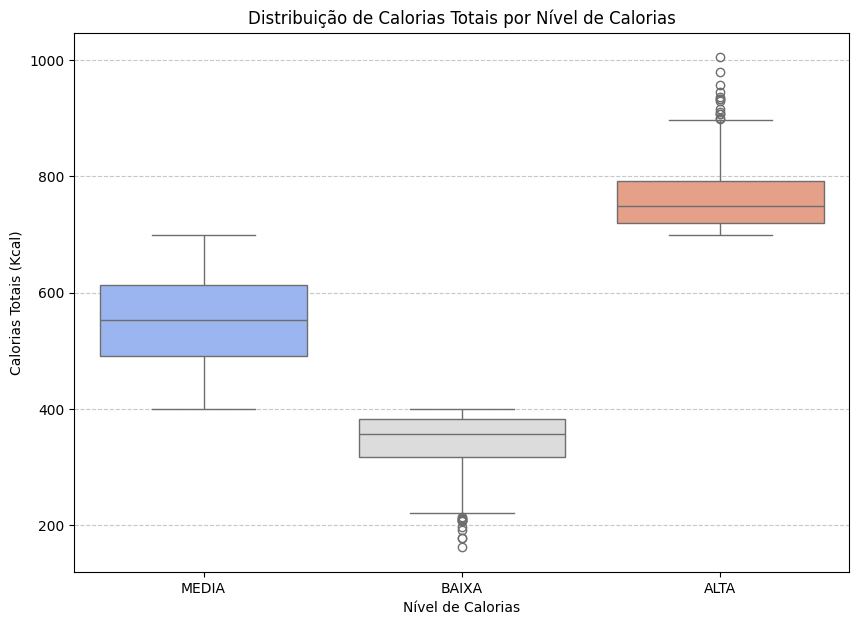

In [ ]:
plt.figure(figsize=(10, 7))
sns.boxplot(x='Nível de Calorias', y='Calorias Totais/Kcal', data=dafr_Refeicao,hue='Nível de Calorias', palette='coolwarm')
plt.title('Distribuição de Calorias Totais por Nível de Calorias')
plt.xlabel('Nível de Calorias')
plt.ylabel('Calorias Totais (Kcal)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

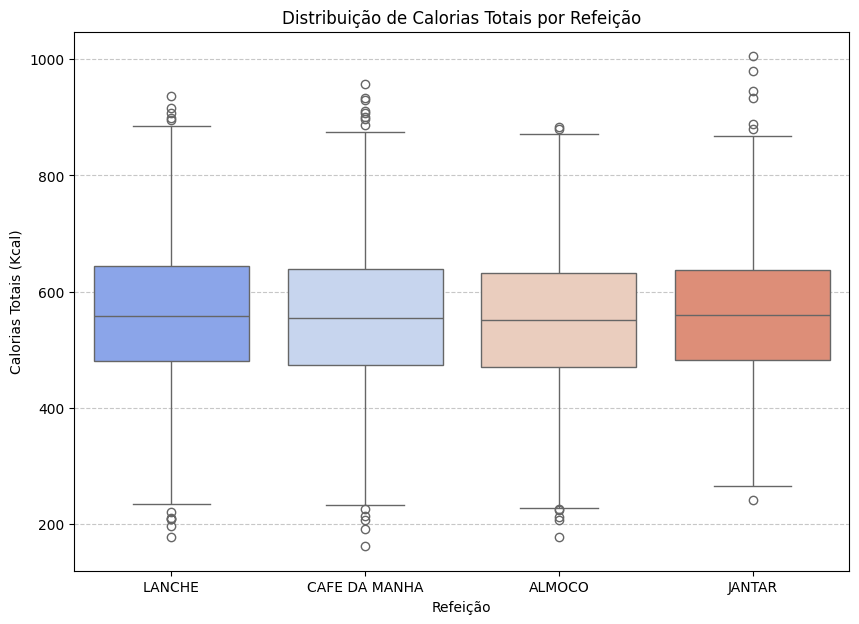

In [ ]:
plt.figure(figsize=(10, 7))
sns.boxplot(x='Refeição', y='Calorias Totais/Kcal', data=dafr_Refeicao,hue='Refeição', palette='coolwarm')
plt.title('Distribuição de Calorias Totais por Refeição')
plt.xlabel('Refeição')
plt.ylabel('Calorias Totais (Kcal)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Qual gráfico seria interessante usar pra mostrar o desvio padrão?

## Histograma

A distribuição de dados descreve como os valores de uma variável se espalham, ou seja, a frequência com que diferentes valores ocorrem. Entender a distribuição é crucial na análise de dados, pois revela padrões, tendências centrais, dispersão e a presença de valores atípicos (outliers). O histograma é uma ferramenta visual fundamental para representar essa distribuição, mostrando a forma dos dados, se são simétricos ou assimétricos, unimodais ou multimodais.

O Histograma serve para visualizar a distribuição de dados de uma variável numérica. Ele mostra a frequência com que diferentes valores ou intervalos de valores (chamados de "bins") ocorrem em um conjunto de dados. Entender a distribuição é crucial na análise de dados, pois revela padrões, tendências centrais, dispersão e a presença de valores atípicos (outliers).

Basicamente, o histograma ajuda a responder perguntas como:

Qual é a forma da distribuição dos meus dados (simétrica, assimétrica, unimodal, multimodal)?
Onde os dados estão mais concentrados?
Existem lacunas ou valores incomuns (outliers)?

### *Calorias Totais*

Alguma curiosidade ou fato importante sobre o atributo que estamos olhando a distribuição?

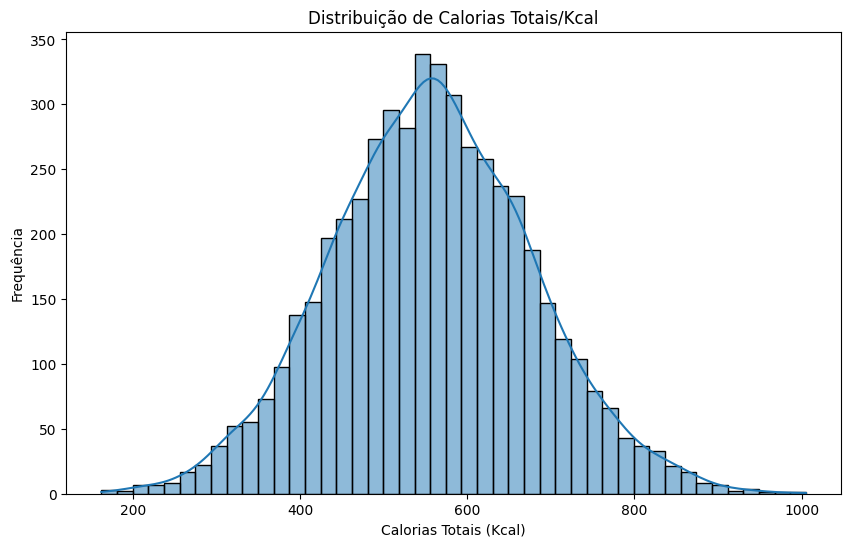

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(dafr_Refeicao['Calorias Totais/Kcal'], kde=True)
plt.title('Distribuição de Calorias Totais/Kcal')
plt.xlabel('Calorias Totais (Kcal)')
plt.ylabel('Frequência')
plt.show()

### *Nível de Calorias*

Alguma curiosidade ou fato importante sobre o atributo que estamos olhando a distribuição?

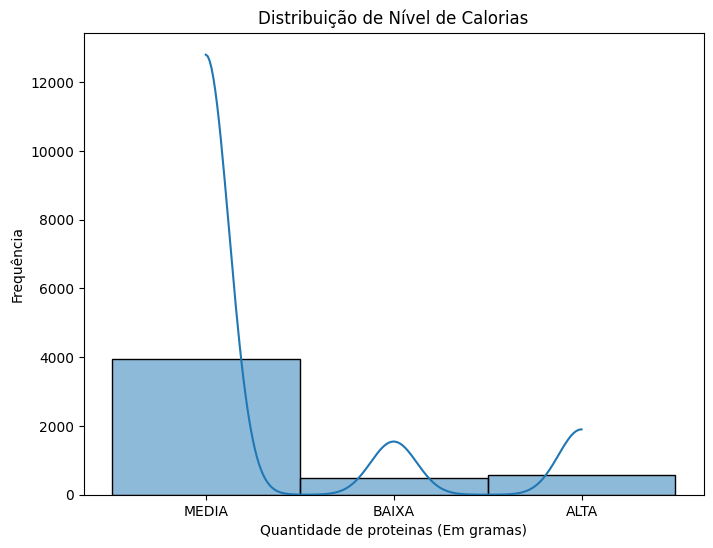

In [ ]:
plt.figure(figsize=(8, 6))
# Histograma do comprimento da sépala (um dos atributos)
sns.histplot(dafr_Refeicao['Nível de Calorias'], kde=True)
plt.title('Distribuição de Nível de Calorias')
plt.xlabel('Quantidade de proteinas (Em gramas)')
plt.ylabel('Frequência')
plt.show()

## *Carboidratos*

Alguma curiosidade ou fato importante sobre o atributo que estamos olhando a distribuição?

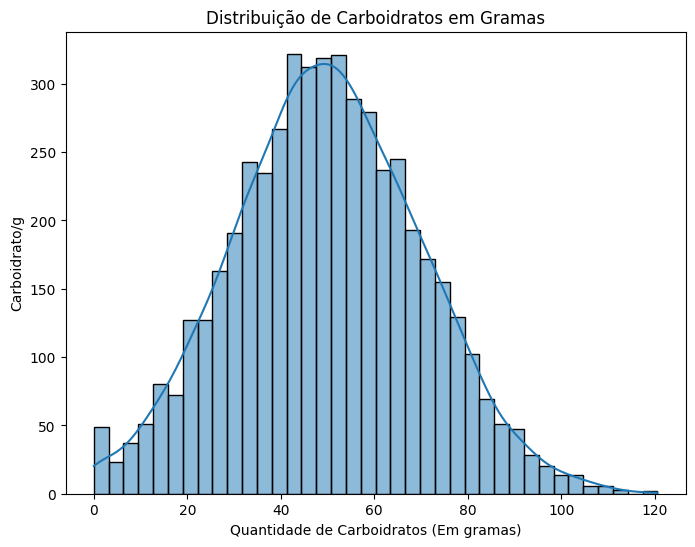

In [ ]:
plt.figure(figsize=(8, 6))
# Histograma do comprimento da sépala (um dos atributos)
sns.histplot(dafr_Refeicao['Carboidrato/g'], kde=True)
plt.title('Distribuição de Carboidratos em Gramas')
plt.xlabel('Quantidade de Carboidratos (Em gramas)')
plt.ylabel('Carboidrato/g')
plt.show()

## *Gordura*

Alguma curiosidade ou fato importante sobre o atributo que estamos olhando a distribuição?

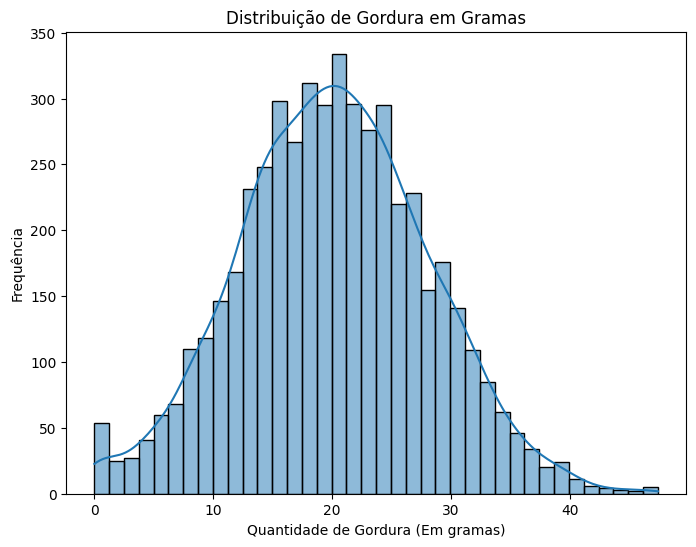

In [ ]:
plt.figure(figsize=(8, 6))
# Histograma do comprimento da sépala (um dos atributos)
sns.histplot(dafr_Refeicao['Gordura/g'], kde=True)
plt.title('Distribuição de Gordura em Gramas')
plt.xlabel('Quantidade de Gordura (Em gramas)')
plt.ylabel('Frequência')
plt.show()

## *FIbra*

Alguma curiosidade ou fato importante sobre o atributo que estamos olhando a distribuição?

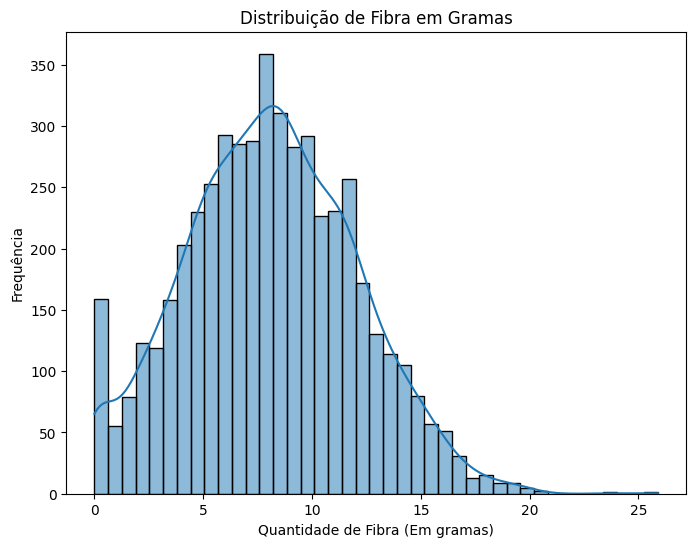

In [ ]:
plt.figure(figsize=(8, 6))
# Histograma do comprimento da sépala (um dos atributos)
sns.histplot(dafr_Refeicao['Fibra/g'], kde=True)
plt.title('Distribuição de Fibra em Gramas')
plt.xlabel('Quantidade de Fibra (Em gramas)')
plt.ylabel('Frequência')
plt.show()

## *Açúcar*

Alguma curiosidade ou fato importante sobre o atributo que estamos olhando a distribuição?

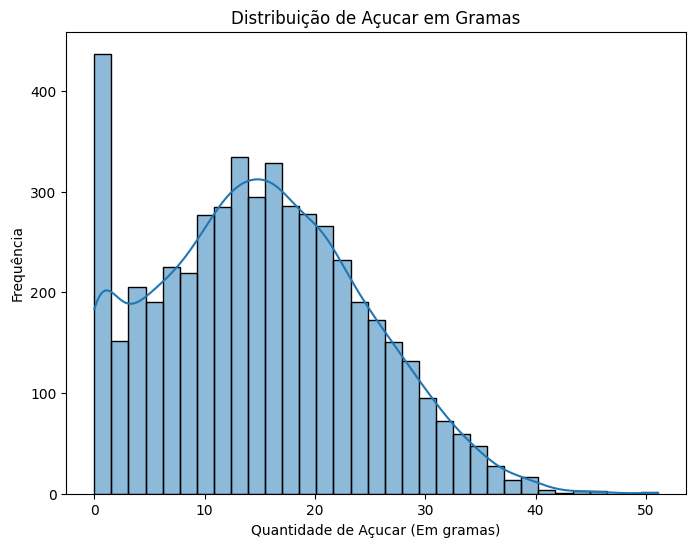

In [ ]:
plt.figure(figsize=(8, 6))
# Histograma do comprimento da sépala (um dos atributos)
sns.histplot(dafr_Refeicao['Açucar/g'], kde=True)
plt.title('Distribuição de Açucar em Gramas')
plt.xlabel('Quantidade de Açucar (Em gramas)')
plt.ylabel('Frequência')
plt.show()

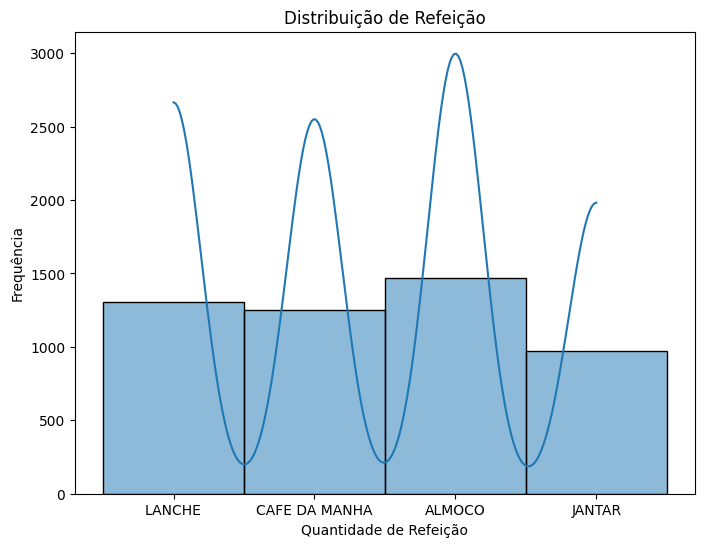

In [ ]:
plt.figure(figsize=(8, 6))
# Histograma do comprimento da sépala (um dos atributos)
sns.histplot(dafr_Refeicao['Refeição'], kde=True)
plt.title('Distribuição de Refeição')
plt.xlabel('Quantidade de Refeição')
plt.ylabel('Frequência')
plt.show()

O histograma mostra a distribuição do comprimento da sépala. A curva de densidade estimada (KDE) nos indica que a distribuição parece bimodal ou multimodal, indicando que as espécies podem ter comprimentos de sépalas diferentes.

### *sepal width*

Alguma curiosidade ou fato importante sobre o atributo que estamos olhando a distribuição?

In [ ]:
plt.figure(figsize=(8, 6))
# Histograma do comprimento da sépala (um dos atributos)
sns.histplot(df['sepal width (cm)'], kde=True)
plt.title('Distribuição da Largura da Sépala')
plt.xlabel('Largura da Sépala (cm)')
plt.ylabel('Frequência')
plt.show()

Quais impressões você tem sobre a distribuição do atributo 'sepal width'?

## Boxplot

Para entender as diferenças entre as espécies, devemos olhar como se comportam os valores quando agrupadas por espécie. Isso nos permite comparar a média, mediana e desvio padrão de cada característica para Iris setosa, Iris versicolor e Iris virginica, além de visualizar suas distribuições por meio de boxplots.


In [ ]:
# Estatísticas descritivas agrupadas por espécie
dafr.groupby('Classes_Calorica').describe()

Proteinas/g                                                  \
                       count       mean       std  min     25%   50%     75%   
Classes_Calorica                                                               
high                   163.0  31.935583  8.595546  9.4  25.450  32.0  37.200   
low                   1248.0  21.020994  9.421050  0.0  14.475  21.3  27.325   
medium                3589.0  26.175508  9.670193  0.0  19.500  26.3  32.600   

                       Carboidratos/g             ... Açucar/g       Calorias  \
                   max          count       mean  ...      75%   max    count   
Classes_Calorica                                  ...                           
high              56.4          163.0  80.871166  ...    23.75  44.3    163.0   
low               56.1         1248.0  32.467708  ...    21.40  51.1   1248.0   
medium            64.3         3589.0  54.486041  ...    21.30  51.0   3589.0   

                                                                            
                        mean        std    min    25%    50%    75%    max  
Classes_Calorica                                                            
high              742.638037  43.325757  700.0  713.5  729.0  753.5  975.0  
low               331.254006  57.040444   56.0  302.0  347.0  377.0  400.0  
medium            520.430203  75.519102  400.0  457.0  512.0  576.0  700.0  

[3 rows x 48 columns]

### *petal length* por Espécie


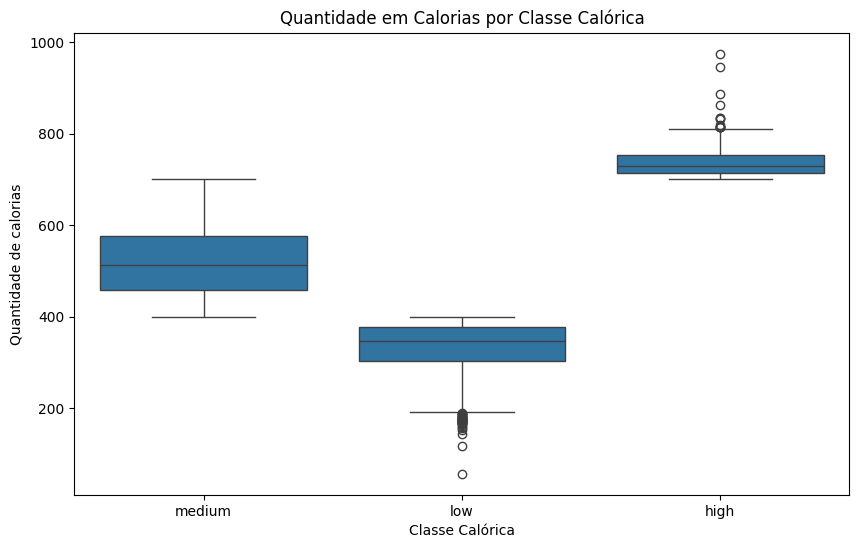

In [ ]:
# Boxplot do comprimento da pétala por espécie
plt.figure(figsize=(10, 6))
sns.boxplot(x='Classes_Calorica', y='Calorias', data=dafr)
plt.title('Quantidade em Calorias por Classe Calórica')
plt.xlabel('Classe Calórica')
plt.ylabel('Quantidade de calorias')
plt.show()

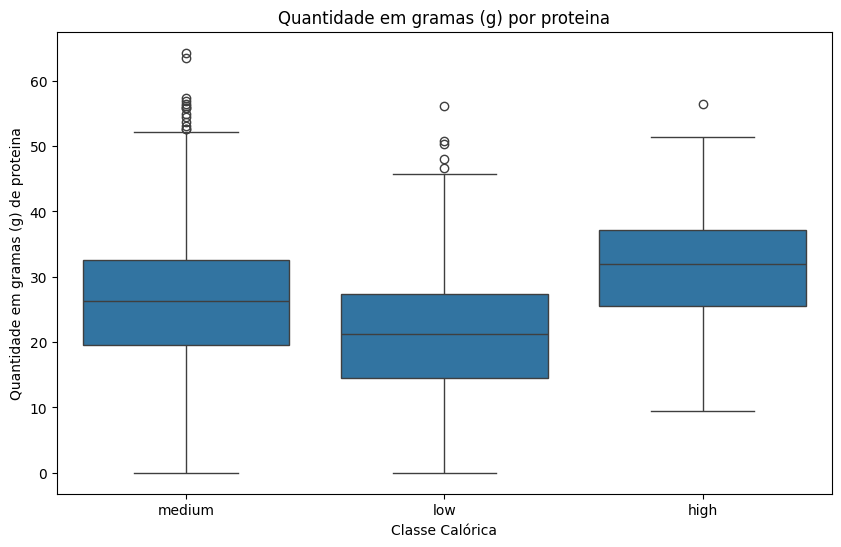

In [ ]:
# Boxplot do comprimento da pétala por espécie
plt.figure(figsize=(10, 6))
sns.boxplot(x='Classes_Calorica', y='Proteinas/g', data=dafr)
plt.title('Quantidade em gramas (g) por proteina')
plt.xlabel('Classe Calórica')
plt.ylabel('Quantidade em gramas (g) de proteina')
plt.show()
#'Proteinas/g', 'Carboidratos/g', 'Gordura/g', 'Fibra/g', 'Açucar/g', 'Calorias', 'Classes_Calorica'

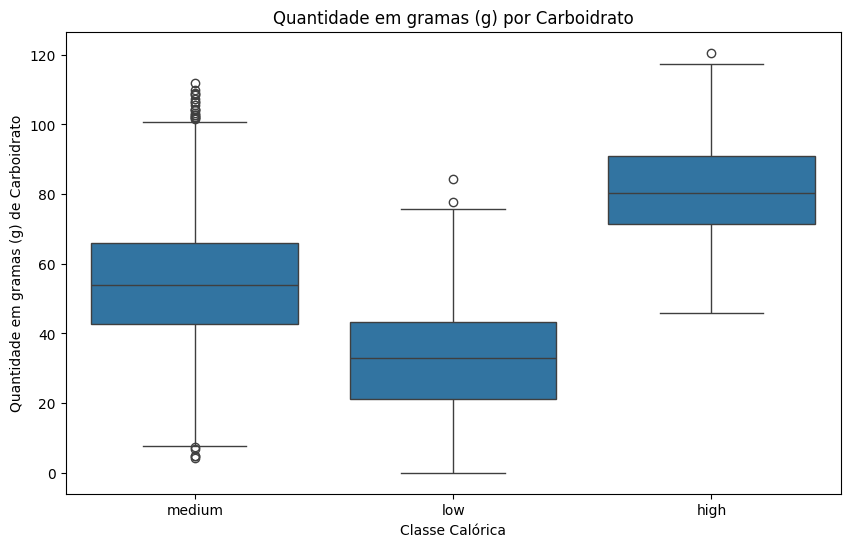

In [ ]:
# Boxplot do comprimento da pétala por espécie
plt.figure(figsize=(10, 6))
sns.boxplot(x='Classes_Calorica', y='Carboidratos/g', data=dafr)
plt.title('Quantidade em gramas (g) por Carboidrato')
plt.xlabel('Classe Calórica')
plt.ylabel('Quantidade em gramas (g) de Carboidrato')
plt.show()
#'Proteinas/g', 'Carboidratos/g', 'Gordura/g', 'Fibra/g', 'Açucar/g', 'Calorias', 'Classes_Calorica'

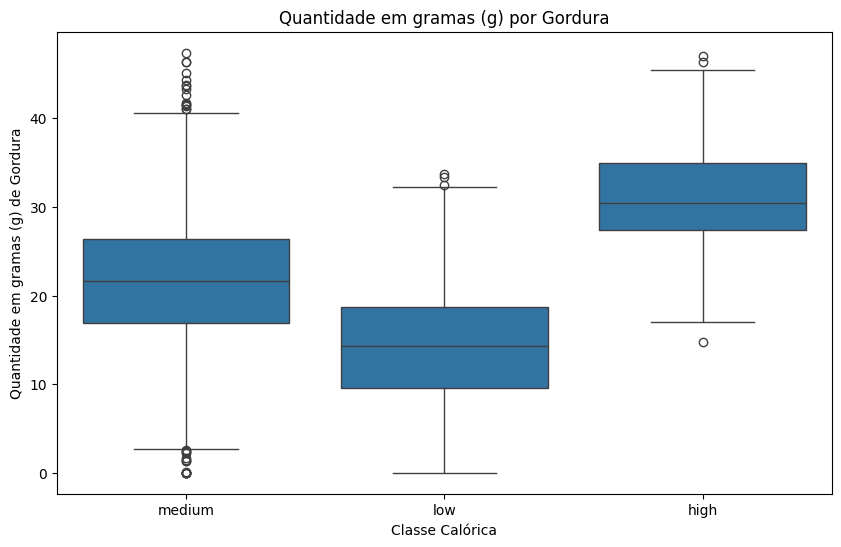

In [ ]:
# Boxplot do comprimento da pétala por espécie
plt.figure(figsize=(10, 6))
sns.boxplot(x='Classes_Calorica', y='Gordura/g', data=dafr)
plt.title('Quantidade em gramas (g) por Gordura')
plt.xlabel('Classe Calórica')
plt.ylabel('Quantidade em gramas (g) de Gordura')
plt.show()
#'Proteinas/g', 'Carboidratos/g', 'Gordura/g', 'Fibra/g', 'Açucar/g', 'Calorias', 'Classes_Calorica'

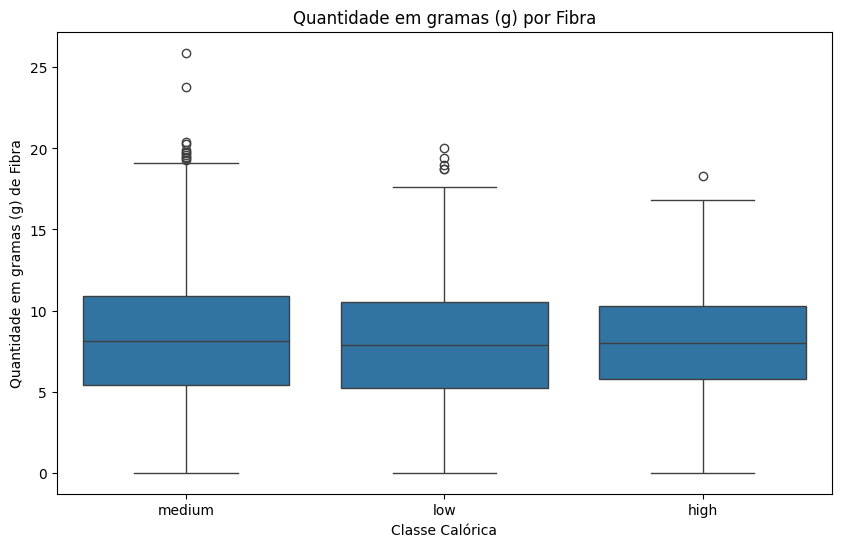

In [ ]:
# Boxplot do comprimento da pétala por espécie
plt.figure(figsize=(10, 6))
sns.boxplot(x='Classes_Calorica', y='Fibra/g', data=dafr)
plt.title('Quantidade em gramas (g) por Fibra')
plt.xlabel('Classe Calórica')
plt.ylabel('Quantidade em gramas (g) de Fibra')
plt.show()
#'Proteinas/g', 'Carboidratos/g', 'Gordura/g', 'Fibra/g', 'Açucar/g', 'Calorias', 'Classes_Calorica'

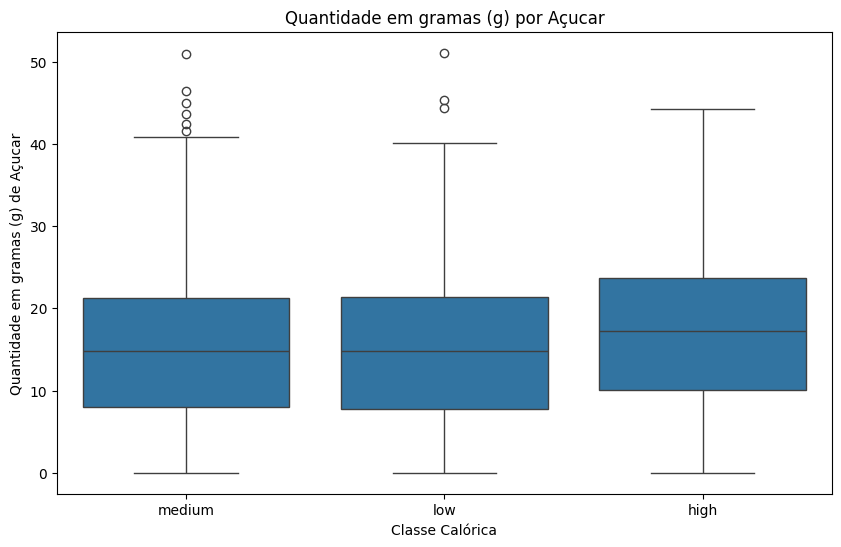

In [ ]:
# Boxplot do comprimento da pétala por espécie
plt.figure(figsize=(10, 6))
sns.boxplot(x='Classes_Calorica', y='Açucar/g', data=dafr)
plt.title('Quantidade em gramas (g) por Açucar')
plt.xlabel('Classe Calórica')
plt.ylabel('Quantidade em gramas (g) de Açucar')
plt.show()
#'Proteinas/g', 'Carboidratos/g', 'Gordura/g', 'Fibra/g', 'Açucar/g', 'Calorias', 'Classes_Calorica'

O boxplot do comprimento da pétala por espécie demonstra claramente que a Iris setosa tem pétalas significativamente mais curtas do que as outras duas espécies. Há uma sobreposição entre Iris versicolor e Iris virginica, mas as medianas e as caixas indicam uma distinção.

### *petal width* por Espécie

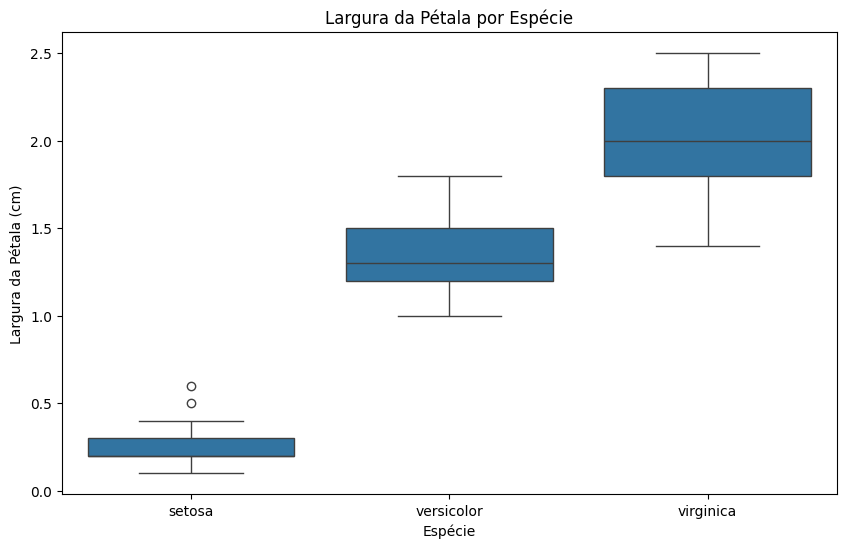

In [ ]:
# Boxplot do comprimento da pétala por espécie
plt.figure(figsize=(10, 6))
sns.boxplot(x='species', y='petal width (cm)', data=df)
plt.title('Largura da Pétala por Espécie')
plt.xlabel('Espécie')
plt.ylabel('Largura da Pétala (cm)')
plt.show()

Quais impressões o boxplot trouxe?

## Matriz de Correlação

A matriz de correlação mede a força e a direção de uma relação linear que os atributos numéricos das espécies podem ter. Valores próximos a 1 indicam uma forte correlação positiva, -1 uma forte correlação negativa, e 0 ausência de correlação linear.

O gráfico de correlação, frequentemente apresentado como um mapa de calor (heatmap), é uma representação visual da matriz de correlação entre múltiplas variáveis numéricas em um conjunto de dados. Ele serve para mostrar a força e a direção da relação linear entre pares de variáveis. As principais características são:

*   **Força da Correlação:** A intensidade da cor em cada célula do gráfico indica a força da correlação. Cores mais fortes (ou mais escuras/claras, dependendo do esquema de cores) significam correlações mais fortes, enquanto cores mais fracas (ou mais claras) indicam correlações mais fracas.
*   **Direção da Correlação:** A cor também pode indicar a direção. Geralmente, tons quentes (como vermelho) representam correlação positiva (quando uma variável aumenta, a outra também tende a aumentar), e tons frios (como azul) representam correlação negativa (quando uma variável aumenta, a outra tende a diminuir).
*   **Valores Numéricos:** Os valores dentro das células (quando annot=True é usado no Seaborn, por exemplo) são os coeficientes de correlação. Esses valores variam de -1 a +1:

     **+1:** Correlação positiva perfeita.

     **-1:** Correlação negativa perfeita.

     **0:** Nenhuma correlação linear.

**O que ele nos ajuda a entender?**

*   **Relações entre Variáveis:** Ajuda a identificar quais variáveis se movem juntas (positiva ou negativamente) e quais são independentes umas das outras.
*   **Seleção de Features:** Em Machine Learning, pode auxiliar na seleção de características, pois variáveis altamente correlacionadas podem ser redundantes, ou variáveis fortemente correlacionadas com a variável alvo são bons preditores.
*   **Validação de Hipóteses:** Ajuda a validar hipóteses sobre como diferentes aspectos do seu conjunto de dados podem estar relacionados.

In [ ]:
# Matriz de correlação
print("\nMatriz de Correlação:")
# Seleciona apenas as colunas numéricas para o cálculo da correlação
numeric_df = dafr_Refeicao.select_dtypes(include=np.number)
print(numeric_df.corr())


Matriz de Correlação:
                         Idade  Proteína/g  Carboidrato/g  Gordura/g  \
Idade                 1.000000   -0.003647       0.005657   0.010203   
Proteína/g           -0.003647    1.000000      -0.002738  -0.001996   
Carboidrato/g         0.005657   -0.002738       1.000000  -0.006142   
Gordura/g             0.010203   -0.001996      -0.006142   1.000000   
Fibra/g              -0.002758    0.002640      -0.014636   0.012373   
Açucar/g             -0.023014    0.016107      -0.005125   0.020137   
Calorias/Kcal         0.010688    0.328377       0.683536   0.594464   
Calorias Totais/Kcal  0.001330    0.330561       0.658285   0.593979   

                       Fibra/g  Açucar/g  Calorias/Kcal  Calorias Totais/Kcal  
Idade                -0.002758 -0.023014       0.010688              0.001330  
Proteína/g            0.002640  0.016107       0.328377              0.330561  
Carboidrato/g        -0.014636 -0.005125       0.683536              0.658285  
Gordura/

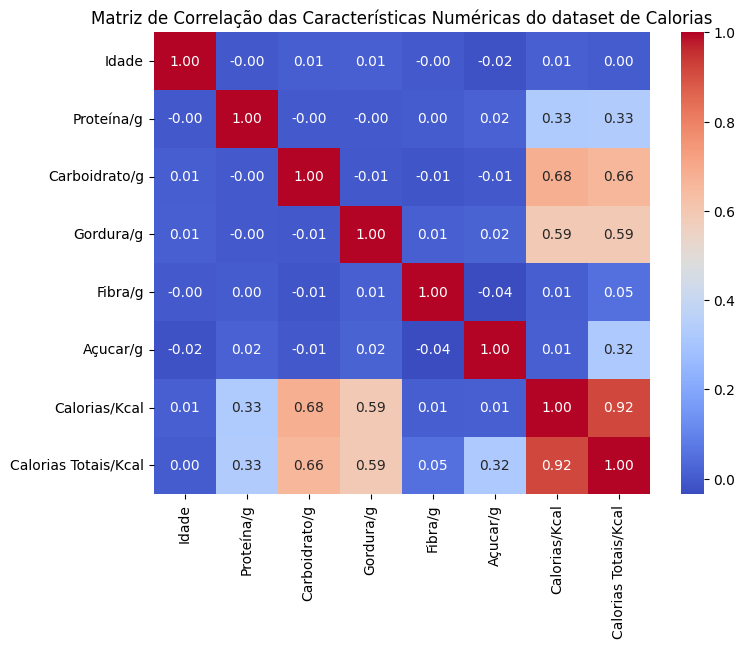

In [ ]:
#cria uma nova figura para o gráfico com um tamanho de 8 polegadas de largura por 6 polegadas de altura.
#Isso ajuda a controlar as dimensões do gráfico para melhor visualização.
plt.figure(figsize=(8, 6))
#Cria o histograma.
# mapa de calor das variáveis numéricas
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Características Numéricas do dataset de Calorias')
plt.show()

O mapa de calor da matriz de correlação revela fortes correlações positivas entre *petal length* e *petal width*, bem como entre *sepal length* e *petal length*/*petal width*. Isso sugere que essas características se movem juntas, o que é útil para a seleção de características.

## Tratamento de Valores Nulos

O dataset Iris original não possui valores nulos. No entanto, o tratamento de valores nulos é crucial e pode envolver imputação (preenchimento com média, mediana, moda) ou remoção de linhas/colunas.

In [ ]:
# Verificar a presença de valores nulos no dataset original
print("Valores nulos no dataset Iris:")
dafr.isnull().sum()

Valores nulos no dataset Iris:


,0
Proteinas/g,0
Carboidratos/g,0
Gordura/g,0
Fibra/g,0
Açucar/g,0
Calorias,0
Classes_Calorica,0


# Pré-Processamento de Dados

O pré-processamento de dados é uma etapa crucial para preparar os dados para modelagem, garantindo que estejam no formato correto e otimizados para o desempenho do algoritmo.

In [ ]:
# Separar features (X) e target (y)
X = dafr.drop('Classes_Calorica', axis=1)
y = dafr['Classes_Calorica']

In [ ]:
# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [ ]:
print(f"Dimensões de X_train: {X_train.shape}")
print(f"Dimensões de X_test: {X_test.shape}")
print(f"Dimensões de y_train: {y_train.shape}")
print(f"Dimensões de y_test: {y_test.shape}")

Dimensões de X_train: (3500, 6)
Dimensões de X_test: (1500, 6)
Dimensões de y_train: (3500,)
Dimensões de y_test: (1500,)


## Normalização

A normalização escala os dados para um intervalo fixo, geralmente entre 0 e 1. É útil quando o algoritmo de machine learning assume que as características estão em uma escala semelhante.



In [ ]:
# Inicializar o MinMaxScaler
scaler_norm = MinMaxScaler()

In [ ]:
# Aprende min e max APENAS de X_train
scaler_norm.fit(X_train)
X_train_normalized = scaler_norm.transform(X_train)
# Usa a média e o desvio padrão aprendidos de X_train
X_test_normalized = scaler_norm.transform(X_test)

In [ ]:
# Exibir as primeiras linhas dos dados normalizados (como DataFrame para melhor visualização)
df_normalized = pd.DataFrame(X_train_normalized, columns=X_train.columns)

In [ ]:
print("\nPrimeiras 5 linhas dos dados normalizados (treino):")
print(df_normalized.head())


Primeiras 5 linhas dos dados normalizados (treino):
   Proteinas/g  Carboidratos/g  Gordura/g   Fibra/g  Açucar/g  Calorias
0     0.359253        0.587894   0.462025  0.316602  0.190196  0.540313
1     0.399689        0.331675   0.459916  0.320463  0.000000  0.404332
2     0.611198        0.071310   0.299578  0.471042  0.550980  0.168472
3     0.427683        0.388060   0.320675  0.386100  0.264706  0.351384
4     0.115086        0.383914   0.495781  0.370656  0.000000  0.368231


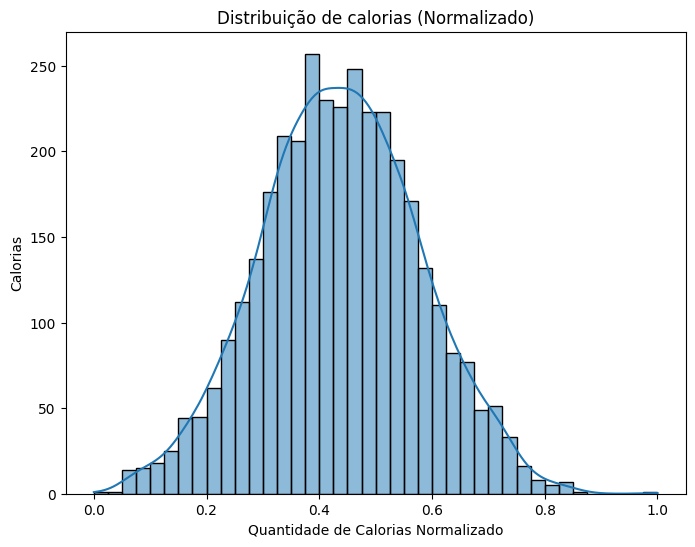

In [ ]:
# Visualização da distribuição após a normalização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_normalized['Calorias'], kde=True)
plt.title('Distribuição de calorias (Normalizado)')
plt.xlabel('Quantidade de Calorias Normalizado')
plt.ylabel('Calorias')
plt.show()
#'Proteinas/g', 'Carboidratos/g', 'Gordura/g', 'Fibra/g', 'Açucar/g', 'Calorias', 'Classes_Calorica'

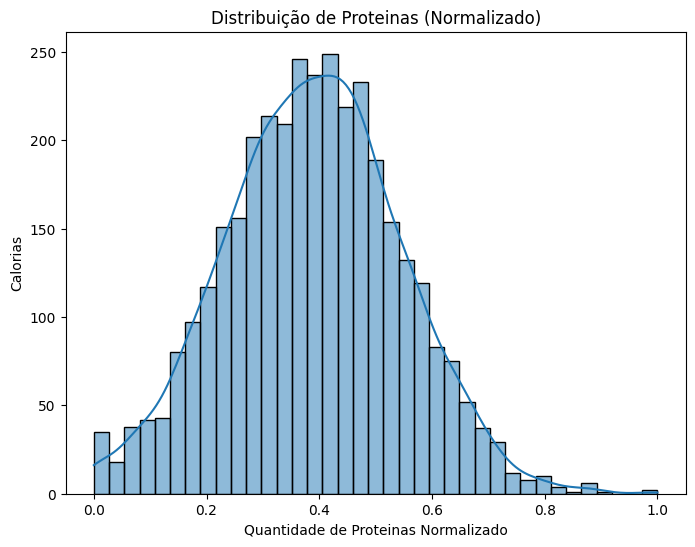

In [ ]:
# Visualização da distribuição após a normalização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_normalized['Proteinas/g'], kde=True)
plt.title('Distribuição de Proteinas (Normalizado)')
plt.xlabel('Quantidade de Proteinas Normalizado')
plt.ylabel('Proteinas')
plt.show()
#'Proteinas/g', 'Carboidratos/g', 'Gordura/g', 'Fibra/g', 'Açucar/g', 'Calorias', 'Classes_Calorica'

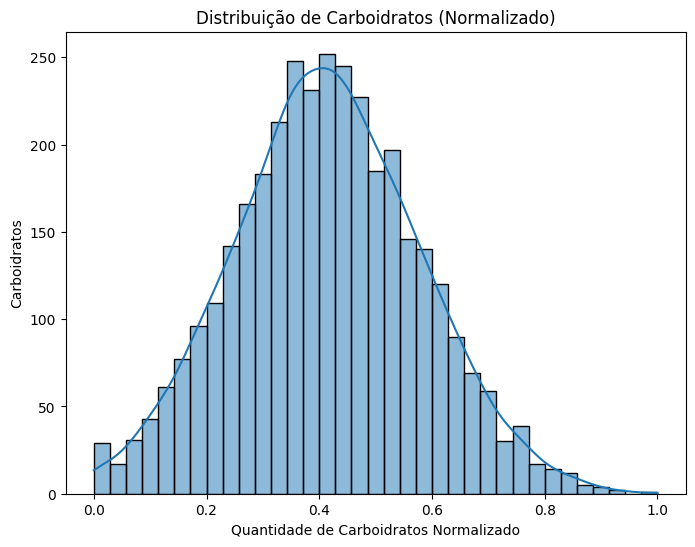

In [ ]:
# Visualização da distribuição após a normalização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_normalized['Carboidratos/g'], kde=True)
plt.title('Distribuição de Carboidratos (Normalizado)')
plt.xlabel('Quantidade de Carboidratos Normalizado')
plt.ylabel('Carboidratos')
plt.show()
#'Proteinas/g', 'Carboidratos/g', 'Gordura/g', 'Fibra/g', 'Açucar/g', 'Calorias', 'Classes_Calorica'

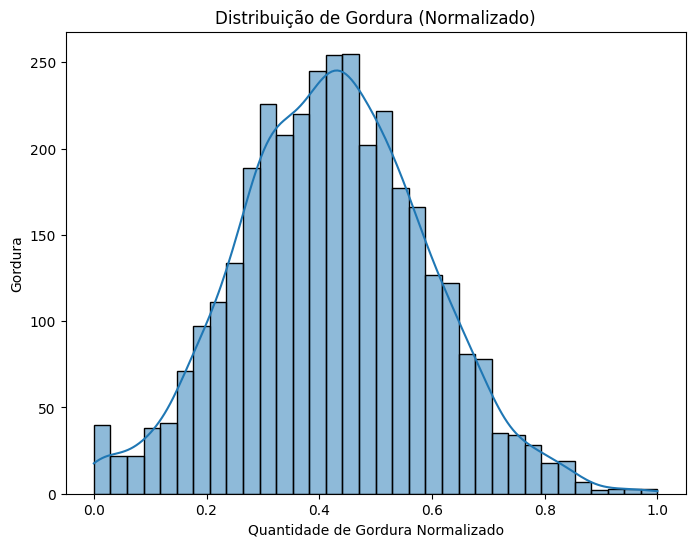

In [ ]:
# Visualização da distribuição após a normalização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_normalized['Gordura/g'], kde=True)
plt.title('Distribuição de Gordura (Normalizado)')
plt.xlabel('Quantidade de Gordura Normalizado')
plt.ylabel('Gordura')
plt.show()
#'Proteinas/g', 'Carboidratos/g', 'Gordura/g', 'Fibra/g', 'Açucar/g', 'Calorias', 'Classes_Calorica'

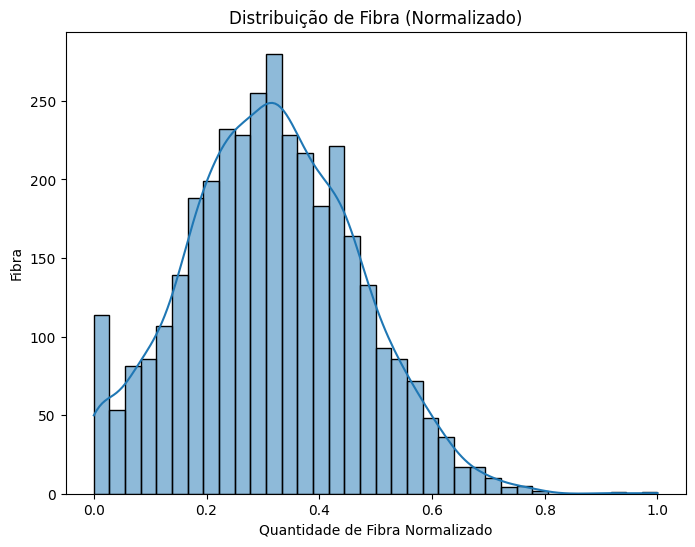

In [ ]:
# Visualização da distribuição após a normalização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_normalized['Fibra/g'], kde=True)
plt.title('Distribuição de Fibra (Normalizado)')
plt.xlabel('Quantidade de Fibra Normalizado')
plt.ylabel('Fibra')
plt.show()
#'Proteinas/g', 'Carboidratos/g', 'Gordura/g', 'Fibra/g', 'Açucar/g', 'Calorias', 'Classes_Calorica'

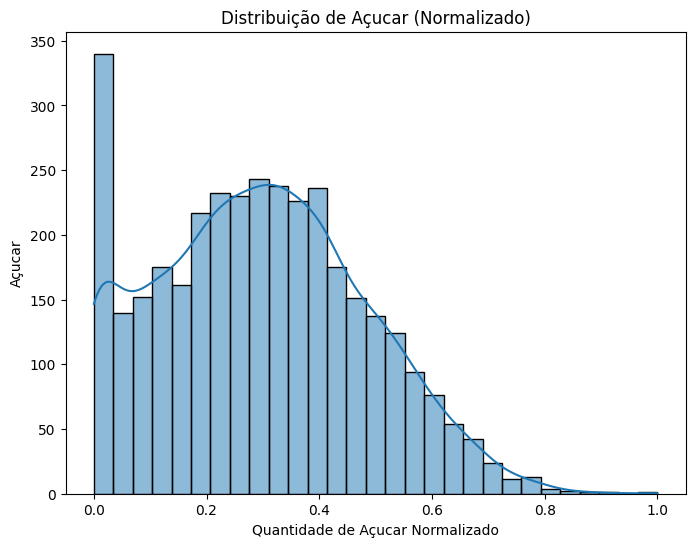

In [ ]:
# Visualização da distribuição após a normalização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_normalized['Açucar/g'], kde=True)
plt.title('Distribuição de Açucar (Normalizado)')
plt.xlabel('Quantidade de Açucar Normalizado')
plt.ylabel('Açucar')
plt.show()
#'Proteinas/g', 'Carboidratos/g', 'Gordura/g', 'Fibra/g', 'Açucar/g', 'Calorias', 'Classes_Calorica'

O histograma de *sepal length* após a normalização mostra que os valores foram escalados para o intervalo de 0 a 1, mantendo a forma da distribuição original.

## Padronização

A padronização (ou Z-score scaling) transforma os dados para ter média 0 e desvio padrão 1. É útil para algoritmos que são sensíveis à escala das características, como SVMs ou redes neurais.

In [ ]:
# Inicializar o StandardScaler
scaler_std = StandardScaler()

In [ ]:
# Aprende média e desvio padrão APENAS de X_train
scaler_std.fit(X_train)
X_train_standardized = scaler_std.transform(X_train)
# Usa a média e o desvio padrão aprendidos de X_train
X_test_standardized = scaler_std.transform(X_test)

In [ ]:
# Exibir as primeiras linhas dos dados padronizados (como DataFrame para melhor visualização)
df_standardized = pd.DataFrame(X_train_standardized, columns=X_train.columns)

In [ ]:
print("\nPrimeiras 5 linhas dos dados padronizados (treino):")
print(df_standardized.head())


Primeiras 5 linhas dos dados padronizados (treino):
   Proteinas/g  Carboidratos/g  Gordura/g   Fibra/g  Açucar/g  Calorias
0    -0.190099        1.061639   0.233419  0.013266 -0.567000  0.730150
1     0.070825       -0.495263   0.220754  0.038693 -1.600837 -0.236142
2     1.435663       -2.077358  -0.741815  1.030360  1.394094 -1.912188
3     0.251466       -0.152644  -0.615161  0.470958 -0.161991 -0.612397
4    -1.765684       -0.177837   0.436065  0.369249 -1.600837 -0.492680


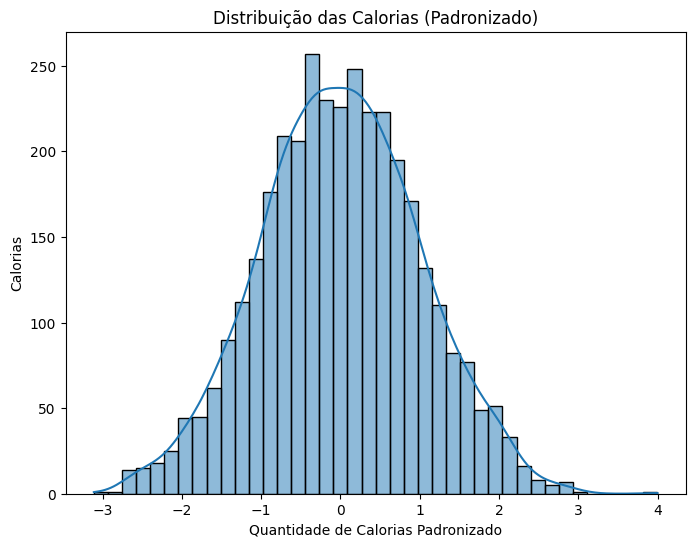

In [ ]:
# Visualização da distribuição após a padronização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_standardized['Calorias'], kde=True)
plt.title('Distribuição das Calorias (Padronizado)')
plt.xlabel('Quantidade de Calorias Padronizado')
plt.ylabel('Calorias')
plt.show()
#'Proteinas/g', 'Carboidratos/g', 'Gordura/g', 'Fibra/g', 'Açucar/g', 'Calorias', 'Classes_Calorica'

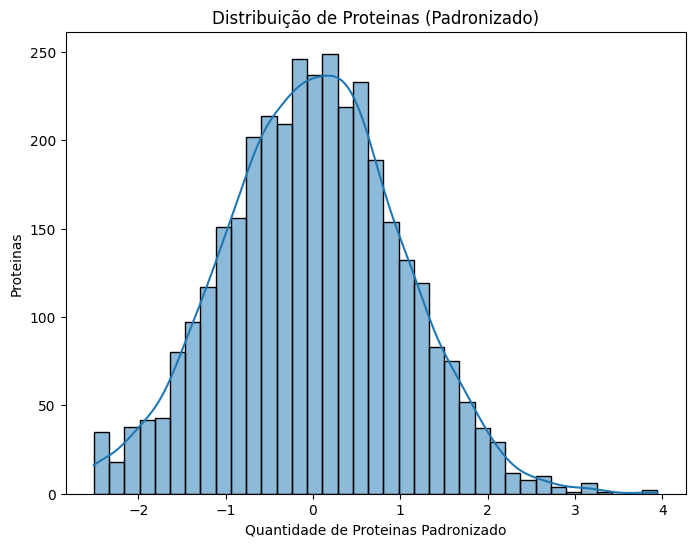

In [ ]:
# Visualização da distribuição após a padronização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_standardized['Proteinas/g'], kde=True)
plt.title('Distribuição de Proteinas (Padronizado)')
plt.xlabel('Quantidade de Proteinas Padronizado')
plt.ylabel('Proteinas')
plt.show()
#'Proteinas/g', 'Carboidratos/g', 'Gordura/g', 'Fibra/g', 'Açucar/g', 'Calorias', 'Classes_Calorica'

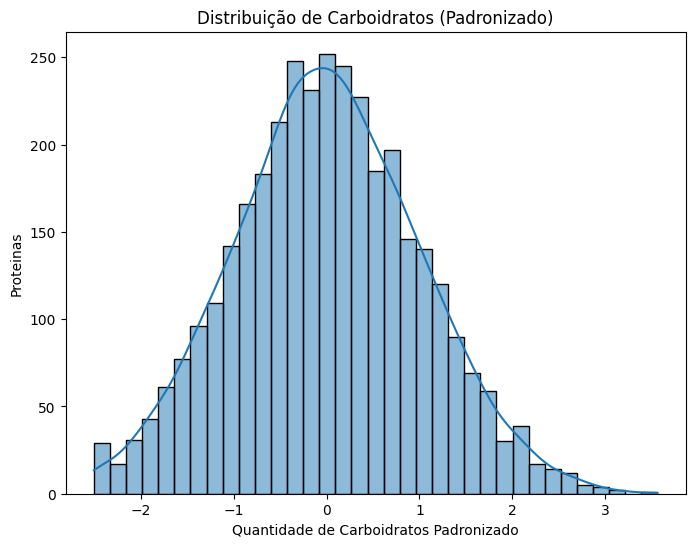

In [ ]:
# Visualização da distribuição após a padronização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_standardized['Carboidratos/g'], kde=True)
plt.title('Distribuição de Carboidratos (Padronizado)')
plt.xlabel('Quantidade de Carboidratos Padronizado')
plt.ylabel('Proteinas')
plt.show()
#'Proteinas/g', 'Carboidratos/g', 'Gordura/g', 'Fibra/g', 'Açucar/g', 'Calorias', 'Classes_Calorica'

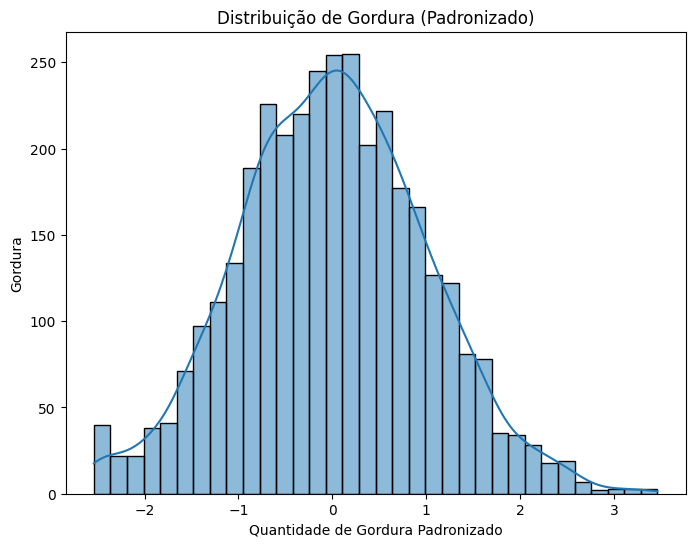

In [ ]:
# Visualização da distribuição após a padronização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_standardized['Gordura/g'], kde=True)
plt.title('Distribuição de Gordura (Padronizado)')
plt.xlabel('Quantidade de Gordura Padronizado')
plt.ylabel('Gordura')
plt.show()
#'Proteinas/g', 'Carboidratos/g', 'Gordura/g', 'Fibra/g', 'Açucar/g', 'Calorias', 'Classes_Calorica'

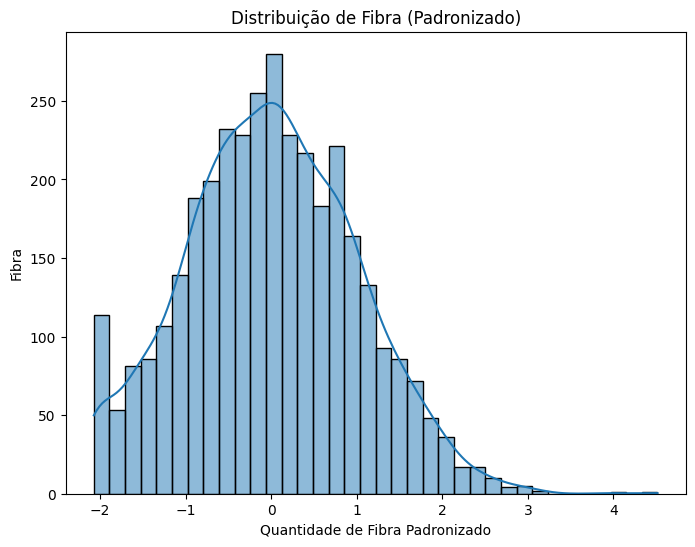

In [ ]:
# Visualização da distribuição após a padronização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_standardized['Fibra/g'], kde=True)
plt.title('Distribuição de Fibra (Padronizado)')
plt.xlabel('Quantidade de Fibra Padronizado')
plt.ylabel('Fibra')
plt.show()
#'Proteinas/g', 'Carboidratos/g', 'Gordura/g', 'Fibra/g', 'Açucar/g', 'Calorias', 'Classes_Calorica'

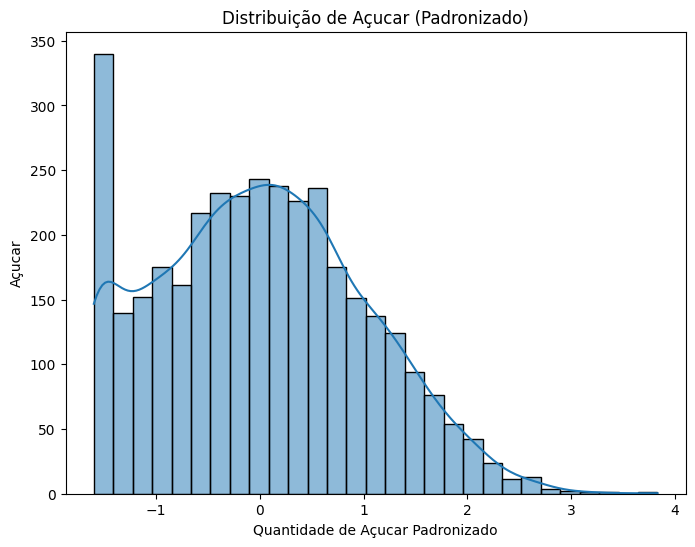

In [ ]:
# Visualização da distribuição após a padronização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_standardized['Açucar/g'], kde=True)
plt.title('Distribuição de Açucar (Padronizado)')
plt.xlabel('Quantidade de Açucar Padronizado')
plt.ylabel('Açucar')
plt.show()
#'Proteinas/g', 'Carboidratos/g', 'Gordura/g', 'Fibra/g', 'Açucar/g', 'Calorias', 'Classes_Calorica'

O histograma de *sepal length* após a padronização mostra que os valores foram transformados para ter uma média próxima de zero e um desvio padrão de um, centralizando a distribuição.

## Outras Transformações e Etapas de Pré-Processamento

Outras etapas de pré-processamento incluem a seleção de características, redução de dimensionalidade (como PCA) ou criação de novas características (feature engineering). O que você faria a mais?



# Respondendo nossas hipóteses

Quais visualizações, tabelas e células descritivas respondem às hipóteses que você levantou?



## Hipótese 1

In [ ]:
# hipótese 1

## Hipótese 2

In [ ]:
# hipótese 2

## Hipótese 3

In [ ]:
# hipótese 3

# Conclusão

A análise e pré-processamento do dataset Iris demonstram a importância de entender a estrutura dos dados antes da modelagem. O dataset é limpo e balanceado, com características numéricas bem definidas que permitem uma clara separação entre as espécies, especialmente a Iris setosa. A análise exploratória revelou correlações importantes entre as características e a eficácia de visualizações como boxplots para distinguir as classes. As etapas de normalização e padronização são fundamentais para preparar os dados para diversos algoritmos de aprendizado de máquina, garantindo que o modelo possa aprender eficientemente com as relações presentes nos dados.

As três hipóteses levantadas foram validadas:

1.   *As diferentes espécies de Íris podem ser distinguidas com base nas medições de suas sépalas e pétalas?* Sim, dado as análises que fizemos no boxplot, observamos um comportamento muito claro e distinto.

2.   *Existe uma correlação entre comprimento da pétala e largura da pétala?* Existe forte correlação entre os atributos *petal length* e *petal width*.

3.   *A espécie Iris setosa é mais facilmente separável das outras duas espécies?* Sim, devido às suas características distintas de menor comprimento e largura da pétala.